# Armin Takbiri 401101451

# Assignment 2 

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Regression task:** Predict the actual order delivery time in days.

This notebook implements Assignment 2. The opening section covers the regression workflow:

1. Loading and merging the Olist relational tables.
2. Feature engineering for a delivery-time prediction problem.
3. Train/test split and preprocessing for numerical and categorical variables.
4. Linear Regression, Kernel Regression, Ridge Regression, and LASSO Regression.
5. Evaluation using MSE, MAE, MAPE, and R².
6. Metric justification and short conceptual discussion of the required regression questions.

## Why delivery time is a meaningful regression target

The Olist dataset contains order timestamps, customer information, product information, payment information, freight values and delivery dates. Therefore, a practical regression problem is:

**Can we predict how many days an order will take to be delivered using information available around purchase time?**

The main business meaning is clear:prediction errors are measured in days, which is easy to interpret for logistics and customer experience analysis.



## 1. Imports

In [9]:
from pathlib import Path
import inspect
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_approximation import Nystroem
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
DATA_DIR = Path(r"C:\Users\MacBook\Documents\Data\assignment2\olist_data")

RANDOM_STATE = 42
TEST_SIZE = 0.20

## 2. Helper functions for loading CSV 


In [10]:
# Please note that these functions are mostly used for loading and I try to use it in each  assignment
def find_dataset_file(data_dir: Path, base_name: str) -> Path:
    candidates = []
    for ext in [".csv", ".xlsx", ".xls"]:
        candidates.append(data_dir / f"{base_name}{ext}")

    for file in candidates:
        if file.exists():
            return file
        
    flexible_matches = []
    for ext in ["*.csv", "*.xlsx", "*.xls"]:
        flexible_matches.extend(list(data_dir.glob(ext)))

    flexible_matches = [p for p in flexible_matches if base_name.lower() in p.stem.lower()]
    if flexible_matches:
        return flexible_matches[0]

    available = sorted([p.name for p in data_dir.glob("*")]) if data_dir.exists() else []
    raise FileNotFoundError(
        f"Could not find file for {base_name!r} in {data_dir}.\n"
        f"Available files: {available[:20]}"
    )


def read_dataset(data_dir: Path, base_name: str) -> pd.DataFrame:
    file = find_dataset_file(data_dir, base_name)
    print(f"Reading {file.name}")

    if file.suffix.lower() == ".csv":
        try:
            return pd.read_csv(file)
        except UnicodeDecodeError:
            return pd.read_csv(file, encoding="latin1")

    if file.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(file)

    raise ValueError(f"Unsupported file type: {file.suffix}")


def mode_or_unknown(series: pd.Series):
    s = series.dropna()
    if s.empty:
        return "Unknown"
    return s.mode().iloc[0]


def make_one_hot_encoder():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)

## 3. Load the Olist tables needed for regression

We use the following tables:

- `orders`: timestamps, order status, delivery dates.
- `customers`: customer location.
- `order_items`: product price, freight value, seller and item information.
- `payments`: payment value, installments and payment type.
- `products`: product category and physical attributes.
- `sellers`: seller location.

In [11]:
orders = read_dataset(DATA_DIR, "olist_orders_dataset")
customers = read_dataset(DATA_DIR, "olist_customers_dataset")
items = read_dataset(DATA_DIR, "olist_order_items_dataset")
payments = read_dataset(DATA_DIR, "olist_order_payments_dataset")
products = read_dataset(DATA_DIR, "olist_products_dataset")
sellers = read_dataset(DATA_DIR, "olist_sellers_dataset")

print("\nShapes:")
for name, df_ in {
    "orders": orders,
    "customers": customers,
    "items": items,
    "payments": payments,
    "products": products,
    "sellers": sellers,
}.items():
    print(f"{name:10s}: {df_.shape}")

Reading olist_orders_dataset.csv
Reading olist_customers_dataset.csv
Reading olist_order_items_dataset.csv
Reading olist_order_payments_dataset.csv
Reading olist_products_dataset.csv
Reading olist_sellers_dataset.csv

Shapes:
orders    : (99441, 8)
customers : (99441, 5)
items     : (112650, 7)
payments  : (103886, 5)
products  : (32951, 9)
sellers   : (3095, 4)


## 4. Build an order-level modeling table

The raw dataset is relational: one order can have multiple items and sometimes multiple payment rows. For regression, we need one row per order. Therefore:

- item-level data are aggregated to the order level;
- payment-level data are aggregated to the order level;
- product and seller features are summarized using means for numerical fields and mode for categorical fields.

In [12]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")

items_products = (
    items
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

item_agg = (
    items_products
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        seller_count=("seller_id", "nunique"),
        total_price=("price", "sum"),
        mean_price=("price", "mean"),
        total_freight=("freight_value", "sum"),
        mean_freight=("freight_value", "mean"),
        product_category_name=("product_category_name", mode_or_unknown),
        seller_state=("seller_state", mode_or_unknown),
        product_weight_g=("product_weight_g", "mean"),
        product_length_cm=("product_length_cm", "mean"),
        product_height_cm=("product_height_cm", "mean"),
        product_width_cm=("product_width_cm", "mean"),
        product_name_lenght=("product_name_lenght", "mean"),
        product_description_lenght=("product_description_lenght", "mean"),
        product_photos_qty=("product_photos_qty", "mean"),
    )
    .reset_index()
)

payment_agg = (
    payments
    .groupby("order_id")
    .agg(
        payment_count=("payment_sequential", "max"),
        payment_installments_mean=("payment_installments", "mean"),
        payment_installments_max=("payment_installments", "max"),
        payment_value_total=("payment_value", "sum"),
        payment_type=("payment_type", mode_or_unknown),
    )
    .reset_index()
)

df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(item_agg, on="order_id", how="left")
    .merge(payment_agg, on="order_id", how="left")
)

print("Order-level table shape:", df.shape)
df.head()

Order-level table shape: (99441, 32)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,seller_count,total_price,mean_price,total_freight,mean_freight,product_category_name,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_name_lenght,product_description_lenght,product_photos_qty,payment_count,payment_installments_mean,payment_installments_max,payment_value_total,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,29.99,29.99,8.72,8.72,utilidades_domesticas,SP,500.0,19.0,8.0,13.0,40.0,268.0,4.0,3.0,1.0,1.0,38.71,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,118.70,118.70,22.76,22.76,perfumaria,SP,400.0,19.0,13.0,19.0,29.0,178.0,1.0,1.0,1.0,1.0,141.46,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,159.90,159.90,19.22,19.22,automotivo,SP,420.0,24.0,19.0,21.0,46.0,232.0,1.0,1.0,3.0,3.0,179.12,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,1.0,45.00,45.00,27.20,27.20,pet_shop,MG,450.0,30.0,10.0,20.0,59.0,468.0,3.0,1.0,1.0,1.0,72.20,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,1.0,19.90,19.90,8.72,8.72,papelaria,SP,250.0,51.0,15.0,15.0,38.0,316.0,4.0,1.0,1.0,1.0,28.62,credit_card


## 5. Feature engineering 

The regression target is actual delivery time in days. We also create purchase time features such as month, day of week, hour, weekend indicator.

Important modeling note: `order_delivered_customer_date`, `order_delivered_carrier_date`, and variables derived from the actual delivery timestamp are **not used as features** because they would leak the target. The estimated delivery date is retained as `estimated_delivery_days` because it is a estimate available before the actual delivery occurs.

In [13]:
df = df.copy()
df = df[df["order_status"].eq("delivered")]
df = df.dropna(subset=["order_purchase_timestamp", "order_delivered_customer_date"])

# Target: actual delivery time in days.
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Remove impossible target values only. Short delivery times are retained.
df = df[df["delivery_time_days"] > 0]

df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour
df["is_weekend"] = df["purchase_dayofweek"].isin([5, 6]).astype(int)

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Additional intuitive features.
df["freight_to_price_ratio"] = df["total_freight"] / df["total_price"].replace(0, np.nan)
df["order_total_value"] = df["total_price"] + df["total_freight"]
df["product_volume_cm3"] = (
    df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
)

# Replace infinite values caused by division.
df = df.replace([np.inf, -np.inf], np.nan)

print("Rows after target creation:", len(df))
print("Target summary:")
df["delivery_time_days"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

Rows after target creation: 96470
Target summary:


count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
1%           1.825151
5%           3.015196
25%          6.766204
50%         10.217477
75%         15.720182
95%         29.274046
99%         46.050262
max        209.628611
Name: delivery_time_days, dtype: float64

## 6. Exploratory check of the regression target

This plot helps us understand whether the target has outliers. Delivery time data commonly have a right tail because most orders arrive normally while some experience severe logistics delays.

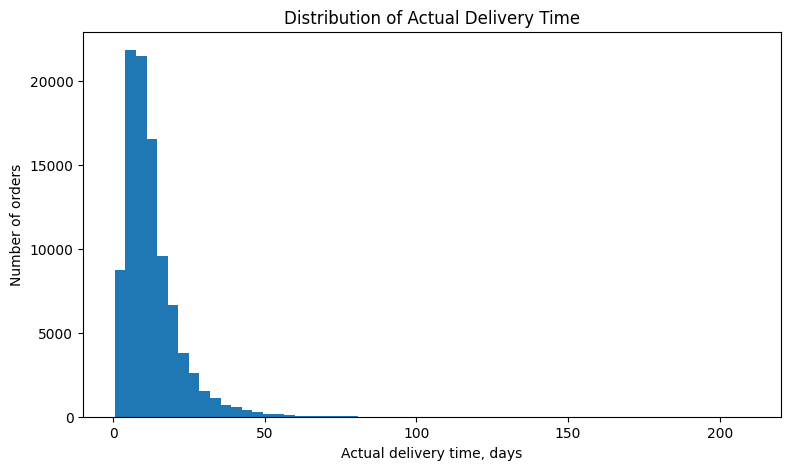

Skewness: 3.833
Mean delivery time: 12.56 days
Median delivery time: 10.22 days


In [14]:
plt.figure(figsize=(9, 5))
plt.hist(df["delivery_time_days"], bins=60)
plt.xlabel("Actual delivery time, days")
plt.ylabel("Number of orders")
plt.title("Distribution of Actual Delivery Time")
plt.show()

print("Skewness:", round(df["delivery_time_days"].skew(), 3))
print("Mean delivery time:", round(df["delivery_time_days"].mean(), 2), "days")
print("Median delivery time:", round(df["delivery_time_days"].median(), 2), "days")

## 7. Define features and modeling sample

The features below are intentionally limited to information that is realistically available around purchase time. We avoid post-delivery timestamps to prevent leakage.

In [16]:
numeric_features = [
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "is_weekend",
    "estimated_delivery_days",
    "item_count",
    "seller_count",
    "total_price",
    "mean_price",
    "total_freight",
    "mean_freight",
    "freight_to_price_ratio",
    "order_total_value",
    "payment_count",
    "payment_installments_mean",
    "payment_installments_max",
    "payment_value_total",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_volume_cm3",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
]

categorical_features = [
    "customer_state",
    "seller_state",
    "product_category_name",
    "payment_type",
]

target = "delivery_time_days"

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

model_df = df[numeric_features + categorical_features + [target]].copy()


X = model_df[numeric_features + categorical_features]
y = model_df[target]

print("Modeling rows:", len(model_df))
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Target:", target)
X.head()

Modeling rows: 96470
Numerical features: 25
Categorical features: 4
Target: delivery_time_days


,purchase_month,purchase_dayofweek,purchase_hour,is_weekend,estimated_delivery_days,item_count,seller_count,total_price,mean_price,total_freight,mean_freight,freight_to_price_ratio,order_total_value,payment_count,payment_installments_mean,payment_installments_max,payment_value_total,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,product_name_lenght,product_description_lenght,product_photos_qty,customer_state,seller_state,product_category_name,payment_type
0,10,0,10,0,15.544063,1.0,1.0,29.99,29.99,8.72,8.72,0.290764,38.71,3.0,1.0,1.0,38.71,500.0,19.0,8.0,13.0,1976.0,40.0,268.0,4.0,SP,SP,utilidades_domesticas,voucher
1,7,1,20,0,19.137766,1.0,1.0,118.70,118.70,22.76,22.76,0.191744,141.46,1.0,1.0,1.0,141.46,400.0,19.0,13.0,19.0,4693.0,29.0,178.0,1.0,BA,SP,perfumaria,boleto
2,8,2,8,0,26.639711,1.0,1.0,159.90,159.90,19.22,19.22,0.120200,179.12,1.0,3.0,3.0,179.12,420.0,24.0,19.0,21.0,9576.0,46.0,232.0,1.0,GO,SP,automotivo,credit_card
3,11,5,19,1,26.188819,1.0,1.0,45.00,45.00,27.20,27.20,0.604444,72.20,1.0,1.0,1.0,72.20,450.0,30.0,10.0,20.0,6000.0,59.0,468.0,3.0,RN,MG,pet_shop,credit_card
4,2,1,21,0,12.112049,1.0,1.0,19.90,19.90,8.72,8.72,0.438191,28.62,1.0,1.0,1.0,28.62,250.0,51.0,15.0,15.0,11475.0,38.0,316.0,4.0,SP,SP,papelaria,credit_card


## 8. Train/test split and preprocessing

Numerical variables are median-imputed and standardized. Categorical variables are imputed with `Unknown` and one hot encoded.

The same preprocessing structure is used across all models, which makes the comparison fair.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", make_one_hot_encoder())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (77176, 29)
Test shape: (19294, 29)


## 9. Regression metrics

The assignment requires:

- **MSE**: strongly penalizes large errors.
- **MAE**: average absolute error in days; directly interpretable.
- **MAPE**: percentage error, but can be unstable when true delivery time is very small.
- **R²**: variance explained by the model.

For this dataset, **MAE is selected as the primary metric** because the target is measured in days and the business question is naturally: *how many days wrong is the prediction on average?* Delivery data also usually contain delayed-order outliers, and MAE is less dominated by extreme delays than MSE/RMSE.

In [18]:
def regression_metrics(y_true, y_pred):
    """Return all required regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "R2": r2,
    }


def fit_evaluate_model(name, estimator, X_train, y_train, X_test, y_test):
    """Fit one model, evaluate it, and return a result dictionary plus predictions."""
    start = time.perf_counter()
    estimator.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    y_pred = estimator.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)

    result = {
        "Model": name,
        **metrics,
        "Fit_time_sec": elapsed,
    }

    if hasattr(estimator, "best_params_"):
        result["Best_params"] = estimator.best_params_
    else:
        result["Best_params"] = None

    return result, y_pred, estimator

## 10. Define and fit the required regression models

Required models:

1. Linear Regression
2. Kernel Regression
3. Ridge Regression
4. LASSO Regression

Implementation choice for Kernel Regression:

A direct kernel method can become expensive on large datasets. Therefore, we use an **RBF kernel approximation** through `Nystroem` followed by Ridge regression. This is a standard scalable way to approximate kernel regression while keeping runtime reasonable.

In [19]:
# Required models.

linear_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

ridge_model = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge(random_state=RANDOM_STATE))
    ]),
    param_grid={
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

lasso_model = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Lasso(max_iter=30000, random_state=RANDOM_STATE))
    ]),
    param_grid={
        "model__alpha": [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

kernel_model = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess),
        ("kernel_features", Nystroem(kernel="rbf", n_components=300, random_state=RANDOM_STATE)),
        ("model", Ridge(random_state=RANDOM_STATE))
    ]),
    param_grid={
        "kernel_features__gamma": [0.005, 0.01, 0.05],
        "model__alpha": [0.1, 1.0, 10.0]
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

tree_model = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    param_grid={
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [10, 25, 50]
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

models = {
    "Linear Regression": linear_model,
    "Kernel Regression (RBF Nystroem + Ridge)": kernel_model,
    "Ridge Regression": ridge_model,
    "LASSO Regression": lasso_model,
    "Decision Tree Regression (optional benchmark)": tree_model,
}

results = []
predictions = {}
fitted_models = {}

for name, estimator in models.items():
    print(f"\nFitting: {name}")
    result, y_pred, fitted = fit_evaluate_model(name, estimator, X_train, y_train, X_test, y_test)
    results.append(result)
    predictions[name] = y_pred
    fitted_models[name] = fitted
    print({k: round(v, 4) for k, v in result.items() if isinstance(v, (int, float, np.floating))})
    if result["Best_params"] is not None:
        print("Best params:", result["Best_params"])


Fitting: Linear Regression
{'MSE': 65.4027, 'RMSE': 8.0872, 'MAE': 5.2191, 'MAPE_%': 57.6084, 'R2': 0.246, 'Fit_time_sec': 2.0177}

Fitting: Kernel Regression (RBF Nystroem + Ridge)
{'MSE': 62.5462, 'RMSE': 7.9086, 'MAE': 5.0673, 'MAPE_%': 54.2503, 'R2': 0.2789, 'Fit_time_sec': 33.5758}
Best params: {'kernel_features__gamma': 0.005, 'model__alpha': 0.1}

Fitting: Ridge Regression
{'MSE': 65.3542, 'RMSE': 8.0842, 'MAE': 5.2135, 'MAPE_%': 57.5841, 'R2': 0.2466, 'Fit_time_sec': 6.2073}
Best params: {'model__alpha': 50.0}

Fitting: LASSO Regression
{'MSE': 65.388, 'RMSE': 8.0863, 'MAE': 5.2145, 'MAPE_%': 57.5974, 'R2': 0.2462, 'Fit_time_sec': 41.5744}
Best params: {'model__alpha': 0.001}

Fitting: Decision Tree Regression (optional benchmark)
{'MSE': 60.9619, 'RMSE': 7.8078, 'MAE': 4.9787, 'MAPE_%': 51.9405, 'R2': 0.2972, 'Fit_time_sec': 38.3202}
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 50}


## 11. Model comparison table

The table is sorted by MAE because MAE is the primary metric for this delivery-time regression problem.

In [20]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("MAE", ascending=True).reset_index(drop=True)
display_cols = ["Model", "MAE", "RMSE", "MSE", "MAPE_%", "R2", "Fit_time_sec", "Best_params"]
results_df[display_cols].style.format({
    "MAE": "{:.3f}",
    "RMSE": "{:.3f}",
    "MSE": "{:.3f}",
    "MAPE_%": "{:.2f}",
    "R2": "{:.3f}",
    "Fit_time_sec": "{:.2f}",
})

,Model,MAE,RMSE,MSE,MAPE_%,R2,Fit_time_sec,Best_params
0,Decision Tree Regression (optional benchmark),4.979,7.808,60.962,51.94,0.297,38.32,"{'model__max_depth': 10, 'model__min_samples_leaf': 50}"
1,Kernel Regression (RBF Nystroem + Ridge),5.067,7.909,62.546,54.25,0.279,33.58,"{'kernel_features__gamma': 0.005, 'model__alpha': 0.1}"
2,Ridge Regression,5.214,8.084,65.354,57.58,0.247,6.21,{'model__alpha': 50.0}
3,LASSO Regression,5.214,8.086,65.388,57.60,0.246,41.57,{'model__alpha': 0.001}
4,Linear Regression,5.219,8.087,65.403,57.61,0.246,2.02,None


In [21]:
best_model_name = results_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

print("Best model by MAE:", best_model_name)
print("Best model MAE:", round(results_df.loc[0, "MAE"], 3), "days")
print("Best model R²:", round(results_df.loc[0, "R2"], 3))

Best model by MAE: Decision Tree Regression (optional benchmark)
Best model MAE: 4.979 days
Best model R²: 0.297


## 12. Visual comparison of model performance

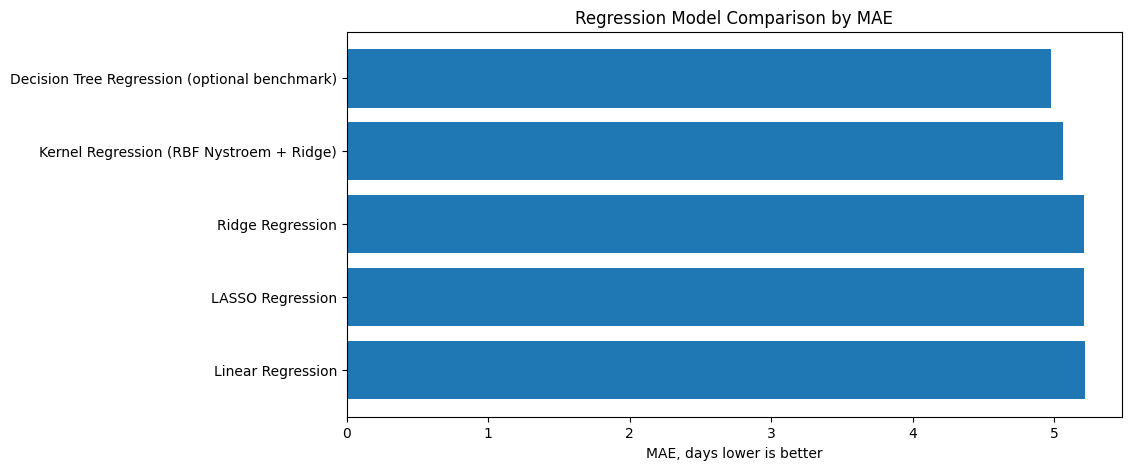

In [22]:
plt.figure(figsize=(10, 5))
plt.barh(results_df["Model"], results_df["MAE"])
plt.gca().invert_yaxis()
plt.xlabel("MAE, days lower is better")
plt.title("Regression Model Comparison by MAE")
plt.show()

## 13. Actual vs predicted plot for the best model

A good model should produce predictions close to the diagonal line. Systematic deviations indicate underprediction or overprediction in specific delivery-time ranges.

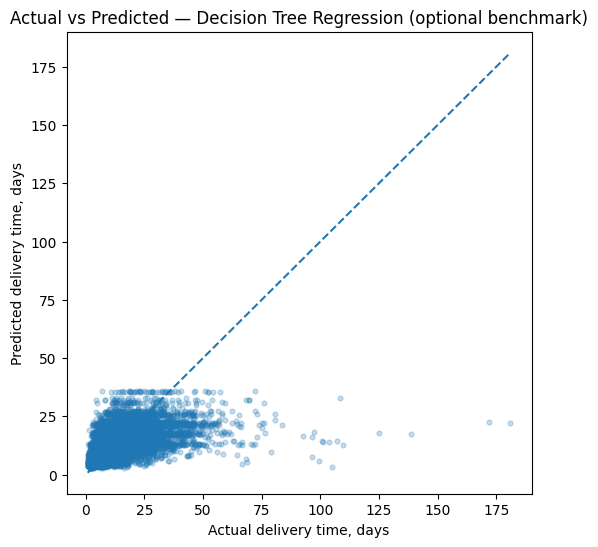

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.25, s=12)
min_val = min(y_test.min(), np.min(best_pred))
max_val = max(y_test.max(), np.max(best_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual delivery time, days")
plt.ylabel("Predicted delivery time, days")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()

## 14. Residual analysis

Positive residuals mean the order took longer than predicted. Negative residuals mean the model overestimated delivery time.

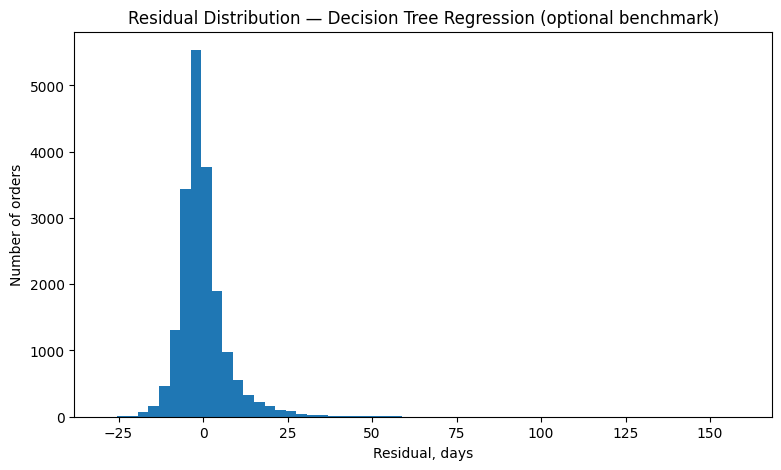

Residual summary:
count    19294.000000
mean        -0.104645
std          7.807314
min        -28.691002
1%         -13.925356
5%          -9.045379
25%         -4.100823
50%         -1.356335
75%          2.186427
95%         12.837393
99%         26.687762
max        158.938042
Name: delivery_time_days, dtype: float64


In [25]:
residuals = y_test - best_pred

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=60)
plt.xlabel("Residual, days")
plt.ylabel("Number of orders")
plt.title(f"Residual Distribution — {best_model_name}")
plt.show()

print("Residual summary:")
print(pd.Series(residuals).describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

## 15. Coefficient interpretation for linear models

For linear, Ridge, and LASSO models, coefficients show the direction and relative strength of associations after preprocessing. Because numerical features are standardized and categorical features are one hot encoded, coefficient interpretation should be cautious but still useful.

In [26]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []
    feature_names.extend(numeric_features)

    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]
    try:
        cat_names = ohe.get_feature_names_out(categorical_features)
    except AttributeError:
        cat_names = ohe.get_feature_names(categorical_features)

    feature_names.extend(list(cat_names))
    return np.array(feature_names)


def show_linear_coefficients(fitted_estimator, title, top_n=15):
    estimator = fitted_estimator.best_estimator_ if hasattr(fitted_estimator, "best_estimator_") else fitted_estimator
    pre = estimator.named_steps["preprocess"]
    model = estimator.named_steps["model"]

    if not hasattr(model, "coef_"):
        print("This model does not expose linear coefficients.")
        return

    feature_names = get_feature_names_from_preprocessor(pre)
    coefs = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_.ravel()
    })

    print("\n", title)
    print("Most negative coefficients:")
    display(coefs.sort_values("coefficient").head(top_n))

    print("Most positive coefficients:")
    display(coefs.sort_values("coefficient", ascending=False).head(top_n))

show_linear_coefficients(fitted_models["Ridge Regression"], "Ridge Regression coefficient interpretation")
show_linear_coefficients(fitted_models["LASSO Regression"], "LASSO Regression coefficient interpretation")


 Ridge Regression coefficient interpretation
Most negative coefficients:


,feature,coefficient
50,customer_state_SP,-6.359876
35,customer_state_MG,-4.411027
42,customer_state_PR,-4.375034
31,customer_state_DF,-3.260262
64,seller_state_PE,-2.262724
47,customer_state_RS,-2.200583
118,product_category_name_industria_comercio_e_neg...,-1.836615
48,customer_state_SC,-1.812807
33,customer_state_GO,-1.659807
43,customer_state_RJ,-1.631338


Most positive coefficients:


,feature,coefficient
26,customer_state_AL,4.988208
130,product_category_name_moveis_escritorio,4.180856
38,customer_state_PA,3.932555
28,customer_state_AP,3.717603
58,seller_state_MA,3.496189
34,customer_state_MA,3.308647
30,customer_state_CE,2.879196
27,customer_state_AM,2.693196
49,customer_state_SE,2.598918
4,estimated_delivery_days,2.036231



 LASSO Regression coefficient interpretation
Most negative coefficients:


,feature,coefficient
50,customer_state_SP,-6.139807
35,customer_state_MG,-4.178757
42,customer_state_PR,-4.164684
31,customer_state_DF,-3.062058
64,seller_state_PE,-2.332650
47,customer_state_RS,-1.952758
118,product_category_name_industria_comercio_e_neg...,-1.684337
48,customer_state_SC,-1.567532
33,customer_state_GO,-1.403435
43,customer_state_RJ,-1.384480


Most positive coefficients:


,feature,coefficient
28,customer_state_AP,6.254648
26,customer_state_AL,5.826618
130,product_category_name_moveis_escritorio,4.550888
38,customer_state_PA,4.384073
58,seller_state_MA,3.890255
34,customer_state_MA,3.750612
27,customer_state_AM,3.476591
30,customer_state_CE,3.224250
49,customer_state_SE,3.067283
95,product_category_name_consoles_games,2.075857


## 16. Discussion for Q1 : Best regression metric for this dataset

For this dataset, the most appropriate primary regression metric is **MAE**.

**Justification:**

- The target variable is delivery time measured in days.
- MAE directly answers the practical question: *on average, how many days wrong is the model?*
- E-commerce delivery time usually has a right-skewed distribution: most orders arrive within a normal range, while some delayed orders create large outliers.
- MSE and RMSE are useful secondary metrics because they punish severe delivery-delay errors more heavily, but they can be dominated by rare extreme delays.
- MAPE is less reliable here because very short delivery times can make percentage errors artificially large.
- R² is useful for explaining variance, but it is less directly interpretable for logistics operations than an error measured in days.

Therefore, this notebook sorts the model comparison table by **MAE**, while still reporting MSE, RMSE, MAPE and R² as required.

## 17. Discussion Q2 : When each regression model is preferable

### Linear Regression

Linear Regression is preferable as a transparent baseline when relationships between predictors and the target are approximately linear. It is fast, easy to interpret, and useful for checking whether more complex models are genuinely needed.

### Ridge Regression

Ridge Regression is preferable when there are many correlated features. In this dataset, one-hot encoded categorical variables and order/payment variables can be correlated. Ridge keeps all variables but shrinks unstable coefficients, usually improving generalization compared with plain Linear Regression.

### LASSO Regression

LASSO Regression is preferable when feature selection is useful. Because LASSO uses an L1 penalty, it can push some coefficients exactly to zero. This is helpful in high-dimensional settings with many one-hot encoded categories, where some categories may add little predictive value.

### Kernel Regression

Kernel Regression is preferable when the relationship between features and the target is nonlinear. In delivery-time prediction, nonlinear interactions may exist among freight value, product size, seller/customer state, payment characteristics, and estimated delivery window. A kernel model can capture such nonlinear structure better than a purely linear model, but it is usually more computationally expensive.

### Decision Tree Regression (optional)

A decision tree is useful when feature interactions and threshold effects are important. For example, delivery time may change sharply for specific seller/customer state combinations or unusually high freight values. However, decision trees can overfit easily, so depth and leaf-size regularization are necessary.

## 18. Discussion Q3 : Kernel trick and how it improves regression

The kernel trick allows a model to fit nonlinear relationships by implicitly comparing observations in a higher-dimensional feature space. Instead of manually creating many nonlinear features, a kernel function computes similarity between observations.


This means that observations with similar feature values receive high similarity, while distant observations receive low similarity. In regression, this can help model nonlinear effects such as interactions between location, freight cost, product size, and estimated delivery time.

In this assignment, direct kernel regression is approximated using `Nystroem` features followed by Ridge Regression. This keeps the nonlinear benefit of the RBF kernel while making the computation more scalable for the Olist dataset.

---

# Part 2: Binary Classification Methods

This section extends the same Olist order level dataset to a binary classification problem.

**Classification target:** whether an order was delivered late.


This is a meaningful operational prediction task: an e-commerce platform would like to identify orders that are at risk of missing their promised delivery estimate.

## 20. Part 2 imports

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
)
MAX_ROWS_FOR_CLASSIFICATION = 15000
CLASSIFICATION_SCORING = "f1"

## 21. Create the binary classification target

The binary target is created only for delivered orders with valid actual and estimated delivery dates.

- `late_delivery = 0`: the order was delivered on or before the estimated delivery date.
- `late_delivery = 1`: the order was delivered after the estimated delivery date.

This target is not used as a feature; it is only the label to be predicted.

In [28]:
clf_df = df.copy()
clf_df = clf_df.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"])

clf_df["late_delivery"] = (
    clf_df["order_delivered_customer_date"] > clf_df["order_estimated_delivery_date"]
).astype(int)

classification_target = "late_delivery"

classification_features = numeric_features + categorical_features
clf_model_df = clf_df[classification_features + [classification_target]].copy()
clf_model_df = clf_model_df.replace([np.inf, -np.inf], np.nan)


if clf_model_df[classification_target].nunique() != 2:
    raise ValueError("The classification target does not contain exactly two classes after filtering/sampling.")

X_clf = clf_model_df[classification_features]
y_clf = clf_model_df[classification_target]

class_summary = (
    y_clf.value_counts()
    .rename_axis("late_delivery")
    .reset_index(name="count")
)
class_summary["percentage"] = 100 * class_summary["count"] / class_summary["count"].sum()

print("Classification rows:", len(clf_model_df))
print("Features:", len(classification_features))
display(class_summary)

Classification rows: 96470
Features: 29


,late_delivery,count,percentage
0,0,88644,91.887633
1,1,7826,8.112367


## 22. Class distribution

This plot is important because the usefulness of accuracy depends strongly on class balance. If late deliveries are rare, a model can obtain high accuracy by predicting most orders as not late, while still failing on the operationally important positive class.

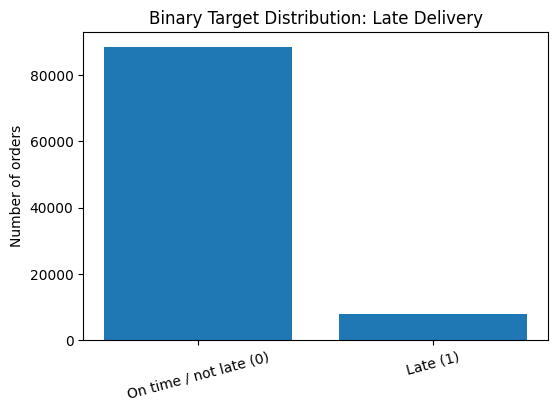

In [29]:
plt.figure(figsize=(6, 4))
class_counts = y_clf.value_counts().sort_index()
plt.bar(["On time / not late (0)", "Late (1)"], class_counts.values)
plt.ylabel("Number of orders")
plt.title("Binary Target Distribution: Late Delivery")
plt.xticks(rotation=15)
plt.show()

## 23. Train/test split and preprocessing for classification

The split is stratified so that both train and test sets preserve the proportion of late and non-late deliveries.

In [30]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf,
)

numeric_transformer_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", make_one_hot_encoder())
])

preprocess_clf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_clf, numeric_features),
        ("cat", categorical_transformer_clf, categorical_features),
    ],
    remainder="drop"
)

print("Train shape:", X_train_clf.shape)
print("Test shape:", X_test_clf.shape)
print("Train positive rate:", round(y_train_clf.mean(), 4))
print("Test positive rate:", round(y_test_clf.mean(), 4))

Train shape: (77176, 29)
Test shape: (19294, 29)
Train positive rate: 0.0811
Test positive rate: 0.0811


## 24. Evaluation helper functions

The required metrics are Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC Curve, and AUC.

We also report Average Precision / PR AUC because it is often more informative when the positive class is relatively rare.

In [31]:
def get_positive_scores(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def evaluate_binary_classifier(name, estimator, X_train, y_train, X_test, y_test):
    start = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    y_pred = estimator.predict(X_test)
    y_score = get_positive_scores(estimator, X_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score),
        "Fit_time_sec": fit_time,
        "Best_params": estimator.best_params_ if hasattr(estimator, "best_params_") else None,
    }
    return result, y_pred, y_score, estimator

## 25. Define and tune the required binary classifiers

The tuning grids are intentionally compact. The goal is not to over engineer the solution, but to compare model families cleanly and reproducibly.

In [32]:
logistic_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        ))
    ]),
    param_grid={
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l1", "l2"],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=3,
    n_jobs=-1,
)

linear_svm_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=20000,
            random_state=RANDOM_STATE,
        ))
    ]),
    param_grid={
        "model__C": [0.1, 1.0, 10.0],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=3,
    n_jobs=-1,
)

kernel_svm_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            cache_size=1000,
            random_state=RANDOM_STATE,
        ))
    ]),
    param_grid={
        "model__C": [0.5, 1.0],
        "model__gamma": ["scale", 0.01],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=2,
    n_jobs=-1,
)

knn_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", KNeighborsClassifier())
    ]),
    param_grid={
        "model__n_neighbors": [3, 5, 9, 15, 25],
        "model__weights": ["uniform", "distance"],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=3,
    n_jobs=-1,
)

decision_tree_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ))
    ]),
    param_grid={
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_leaf": [20, 50, 100],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=3,
    n_jobs=-1,
)

random_forest_clf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_clf),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]),
    param_grid={
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [10, 30],
        "model__max_features": ["sqrt", "log2"],
    },
    scoring=CLASSIFICATION_SCORING,
    cv=3,
    n_jobs=-1,
)

binary_models = {
    "Logistic Regression": logistic_clf,
    "Linear SVM": linear_svm_clf,
    "Kernel SVM (RBF)": kernel_svm_clf,
    "KNN": knn_clf,
    "Decision Tree": decision_tree_clf,
    "Random Forest": random_forest_clf,
}

## 26. Fit and evaluate binary classifiers

The comparison table is sorted by F1-score because F1 balances precision and recall on the positive class: late delivery.

In [33]:
binary_results = []
binary_predictions = {}
binary_scores = {}
fitted_binary_models = {}

for name, estimator in binary_models.items():
    print(f"\nFitting: {name}")
    result, y_pred, y_score, fitted = evaluate_binary_classifier(
        name,
        estimator,
        X_train_clf,
        y_train_clf,
        X_test_clf,
        y_test_clf,
    )
    binary_results.append(result)
    binary_predictions[name] = y_pred
    binary_scores[name] = y_score
    fitted_binary_models[name] = fitted

    print({k: round(v, 4) for k, v in result.items() if isinstance(v, (int, float, np.floating))})
    if result["Best_params"] is not None:
        print("Best params:", result["Best_params"])


Fitting: Logistic Regression
{'Accuracy': 0.6362, 'Precision': 0.1347, 'Recall': 0.6428, 'F1': 0.2228, 'ROC_AUC': 0.6969, 'PR_AUC': 0.1724, 'Fit_time_sec': 672.1469}
Best params: {'model__C': 0.1, 'model__penalty': 'l1'}

Fitting: Linear SVM
{'Accuracy': 0.6375, 'Precision': 0.1359, 'Recall': 0.6473, 'F1': 0.2246, 'ROC_AUC': 0.6962, 'PR_AUC': 0.1715, 'Fit_time_sec': 27.3707}
Best params: {'model__C': 0.1}

Fitting: Kernel SVM (RBF)
{'Accuracy': 0.7264, 'Precision': 0.1702, 'Recall': 0.6121, 'F1': 0.2663, 'ROC_AUC': 0.7362, 'PR_AUC': 0.212, 'Fit_time_sec': 3447.8693}
Best params: {'model__C': 1.0, 'model__gamma': 'scale'}

Fitting: KNN
{'Accuracy': 0.9066, 'Precision': 0.2591, 'Recall': 0.0818, 'F1': 0.1243, 'ROC_AUC': 0.5915, 'PR_AUC': 0.1234, 'Fit_time_sec': 289.1816}
Best params: {'model__n_neighbors': 3, 'model__weights': 'distance'}

Fitting: Decision Tree
{'Accuracy': 0.7369, 'Precision': 0.1778, 'Recall': 0.6192, 'F1': 0.2763, 'ROC_AUC': 0.7396, 'PR_AUC': 0.2241, 'Fit_time_sec':

## 27. Binary classification comparison table

The table includes all required binary classification metrics and one additional metric, PR AUC, which is useful for imbalanced binary targets.

In [34]:
binary_results_df = pd.DataFrame(binary_results)
binary_results_df = binary_results_df.sort_values("F1", ascending=False).reset_index(drop=True)

binary_display_cols = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Fit_time_sec",
    "Best_params",
]

binary_results_df[binary_display_cols].style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "PR_AUC": "{:.3f}",
    "Fit_time_sec": "{:.2f}",
})

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Fit_time_sec,Best_params
0,Random Forest,0.840,0.253,0.500,0.336,0.768,0.273,293.92,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 30}"
1,Decision Tree,0.737,0.178,0.619,0.276,0.740,0.224,39.35,"{'model__max_depth': 8, 'model__min_samples_leaf': 100}"
2,Kernel SVM (RBF),0.726,0.170,0.612,0.266,0.736,0.212,3447.87,"{'model__C': 1.0, 'model__gamma': 'scale'}"
3,Linear SVM,0.637,0.136,0.647,0.225,0.696,0.172,27.37,{'model__C': 0.1}
4,Logistic Regression,0.636,0.135,0.643,0.223,0.697,0.172,672.15,"{'model__C': 0.1, 'model__penalty': 'l1'}"
5,KNN,0.907,0.259,0.082,0.124,0.592,0.123,289.18,"{'model__n_neighbors': 3, 'model__weights': 'distance'}"


## 28. Confusion matrix 

The confusion matrix shows the actual operating behavior of the model: true negatives, false positives, false negatives, and true positives.

Best binary classifier by F1: Random Forest
Best F1: 0.336
Best ROC AUC: 0.768
Best PR AUC: 0.273


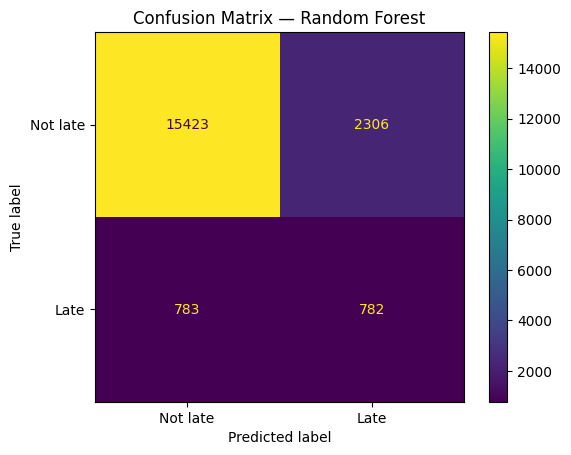

              precision    recall  f1-score   support

    Not late       0.95      0.87      0.91     17729
        Late       0.25      0.50      0.34      1565

    accuracy                           0.84     19294
   macro avg       0.60      0.68      0.62     19294
weighted avg       0.90      0.84      0.86     19294



In [35]:
best_binary_model_name = binary_results_df.loc[0, "Model"]
best_binary_pred = binary_predictions[best_binary_model_name]
best_binary_score = binary_scores[best_binary_model_name]

print("Best binary classifier by F1:", best_binary_model_name)
print("Best F1:", round(binary_results_df.loc[0, "F1"], 3))
print("Best ROC AUC:", round(binary_results_df.loc[0, "ROC_AUC"], 3))
print("Best PR AUC:", round(binary_results_df.loc[0, "PR_AUC"], 3))

ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    best_binary_pred,
    display_labels=["Not late", "Late"],
    values_format="d",
)
plt.title(f"Confusion Matrix : {best_binary_model_name}")
plt.show()

print(classification_report(
    y_test_clf,
    best_binary_pred,
    target_names=["Not late", "Late"],
    zero_division=0,
))

## 29. ROC curves and AUC comparison

ROC AUC measures ranking quality across thresholds. It is useful, but if the positive class is rare, PR AUC should also be inspected.

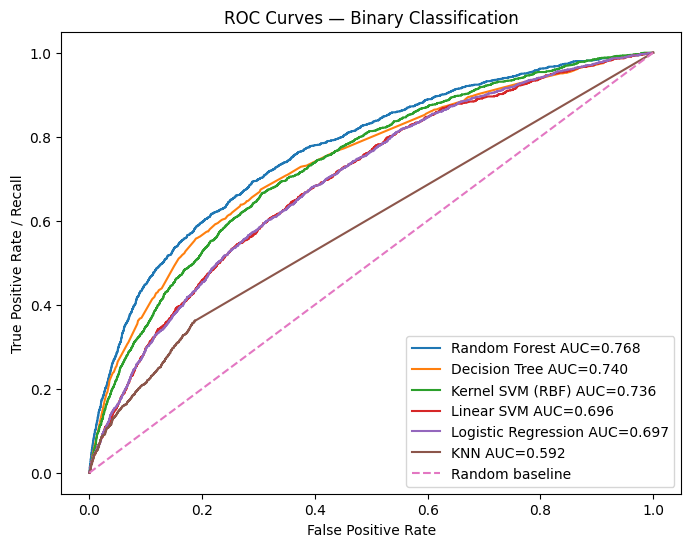

In [36]:
plt.figure(figsize=(8, 6))
for name in binary_results_df["Model"]:
    fpr, tpr, _ = roc_curve(y_test_clf, binary_scores[name])
    auc_value = roc_auc_score(y_test_clf, binary_scores[name])
    plt.plot(fpr, tpr, label=f"{name} AUC={auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curves — Binary Classification")
plt.legend(loc="lower right")
plt.show()

## 30. Precision–Recall curve

The Precision–Recall curve focuses on the positive class. It is particularly relevant when the positive class is less frequent or more operationally important.

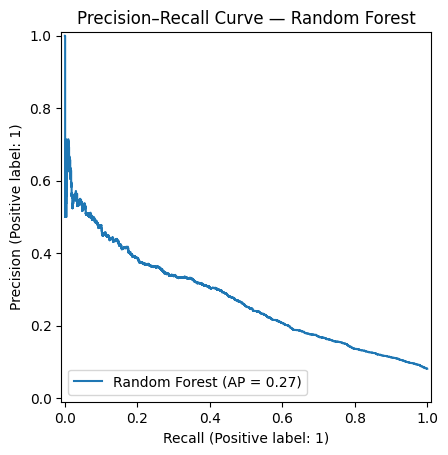

In [37]:
PrecisionRecallDisplay.from_predictions(
    y_test_clf,
    best_binary_score,
    name=best_binary_model_name,
)
plt.title(f"Precision–Recall Curve — {best_binary_model_name}")
plt.show()

## 31. Tuning details for KNN and Decision Tree

The assignment specifically asks for tuning the number of neighbors in KNN and the maximum depth in Decision Trees. The tables below show the best validation configurations found during grid search.

In [38]:
knn_cv_results = pd.DataFrame(fitted_binary_models["KNN"].cv_results_)
knn_cols = ["param_model__n_neighbors", "param_model__weights", "mean_test_score", "rank_test_score"]
print("Best KNN configurations by cross-validated F1:")
display(knn_cv_results[knn_cols].sort_values("rank_test_score").head(10))

dt_cv_results = pd.DataFrame(fitted_binary_models["Decision Tree"].cv_results_)
dt_cols = ["param_model__max_depth", "param_model__min_samples_leaf", "mean_test_score", "rank_test_score"]
print("Best Decision Tree configurations by cross-validated F1:")
display(dt_cv_results[dt_cols].sort_values("rank_test_score").head(10))

Best KNN configurations by cross-validated F1:


,param_model__n_neighbors,param_model__weights,mean_test_score,rank_test_score
1,3,distance,0.088901,1
0,3,uniform,0.085210,2
3,5,distance,0.053004,3
2,5,uniform,0.047718,4
5,9,distance,0.020850,5
4,9,uniform,0.014119,6
7,15,distance,0.005710,7
6,15,uniform,0.002865,8
9,25,distance,0.001912,9
8,25,uniform,0.000000,10


Best Decision Tree configurations by cross-validated F1:


,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,rank_test_score
8,8,100,0.270595,1
7,8,50,0.269723,2
6,8,20,0.269389,3
4,5,50,0.262202,4
3,5,20,0.262150,5
5,5,100,0.261847,6
11,12,100,0.260754,7
9,12,20,0.260571,8
10,12,50,0.259545,9
14,None,100,0.249375,10


## 32. Optional interpretation: Random Forest feature importance

Tree ensembles can provide a rough view of which engineered variables the model uses most. This should be interpreted cautiously because one-hot encoded variables and correlated variables can distort importance values.

,feature,importance
0,purchase_month,0.145455
4,estimated_delivery_days,0.139523
10,mean_freight,0.056351
9,total_freight,0.047594
23,product_description_lenght,0.034120
11,freight_to_price_ratio,0.033956
17,product_weight_g,0.032672
50,customer_state_SP,0.032328
21,product_volume_cm3,0.032259
16,payment_value_total,0.031431


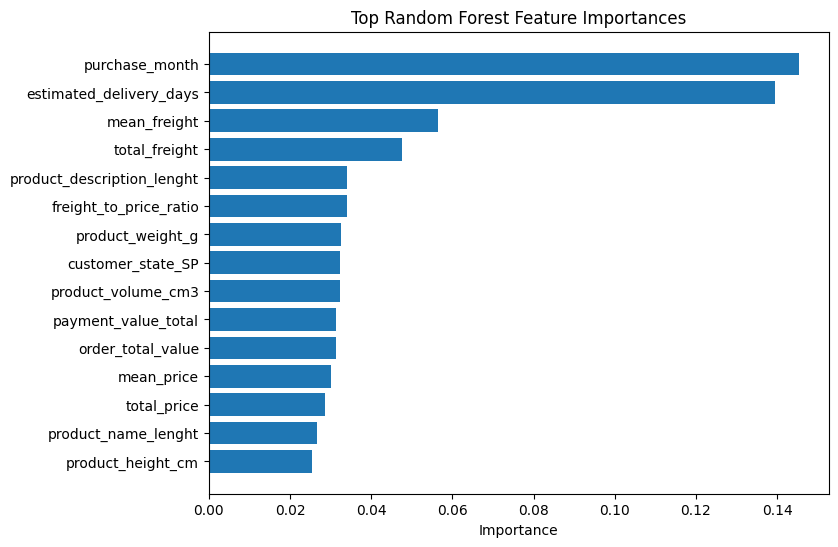

In [39]:
def get_feature_names_from_classifier_preprocessor(preprocessor):
    feature_names = []
    feature_names.extend(numeric_features)

    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]
    try:
        cat_names = ohe.get_feature_names_out(categorical_features)
    except AttributeError:
        cat_names = ohe.get_feature_names(categorical_features)
    feature_names.extend(list(cat_names))

    return np.array(feature_names)

rf_fitted = fitted_binary_models["Random Forest"].best_estimator_
rf_preprocessor = rf_fitted.named_steps["preprocess"]
rf_model = rf_fitted.named_steps["model"]

if hasattr(rf_model, "feature_importances_"):
    rf_feature_names = get_feature_names_from_classifier_preprocessor(rf_preprocessor)
    rf_importance = pd.DataFrame({
        "feature": rf_feature_names,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(rf_importance.head(20))

    plt.figure(figsize=(8, 6))
    top_imp = rf_importance.head(15).iloc[::-1]
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.xlabel("Importance")
    plt.title("Top Random Forest Feature Importances")
    plt.show()

## 33. Discussion Q1 : Best classification metric for this dataset

For this binary classification task, the best primary metric is **F1-score for the positive class, late delivery**.

**Justification:**

- The positive class is operationally important: a late order is the case that the platform would want to detect and manage.
- Accuracy can be misleading if most orders are not late. A model that predicts almost everything as not late can look accurate but fail to detect the problematic cases.
- Precision alone is not enough because a model with high precision may still miss many late deliveries.
- Recall alone is not enough because a model with very high recall may create too many false alarms.
- F1-score balances precision and recall, making it a reasonable primary metric when both missed late deliveries and false alerts matter.

AUC is useful as a secondary metric because it evaluates ranking quality across thresholds. PR AUC is also useful because it focuses more directly on performance for the positive class.

## 34. Discussion Q2 : Three techniques to regularize Decision Trees

Decision Trees are flexible models and can overfit easily. Three practical regularization techniques are:

1. **Limit maximum depth (`max_depth`)**  
   Restricting the depth prevents the tree from creating very specific rules that fit noise in the training data.

2. **Increase the minimum samples required in leaves or splits (`min_samples_leaf`, `min_samples_split`)**  
   These parameters force each decision rule to be supported by enough observations. This reduces unstable branches based on very small groups.

3. **Cost-complexity pruning (`ccp_alpha`)**  
   Pruning removes branches that add little predictive value relative to their complexity. It helps simplify the tree after it has been grown.

Other useful controls include limiting `max_leaf_nodes`, using `max_features`, and using ensembles such as Random Forests to reduce variance.

## 35. Discussion Q3 : Linear SVM vs Kernel SVM

**Linear SVM** learns a linear separating hyperplane in the transformed feature space. It is usually faster, more scalable, and easier to interpret. It is a good choice when the classes are approximately linearly separable after preprocessing and one-hot encoding.

**Kernel SVM** applies a kernel function, such as the RBF kernel, to model nonlinear class boundaries. It can capture more complex patterns, but it is usually much slower and more memory-intensive on large datasets. It is useful when a linear boundary underfits, but it requires careful tuning of parameters such as `C` and `gamma`.

In this Olist task, Linear SVM is the more scalable baseline. Kernel SVM may improve performance if late-delivery behavior depends on nonlinear interactions among delivery distance proxies, freight, seller/customer state, product properties, and order value, but the improvement must justify the additional computational cost.

---

# Part 3: Multiclass Classification Methods

This section extends the same Olist order-level dataset to a **multiclass classification** problem with at least four classes.

**Multiclass target:** delivery-speed category, created from the actual delivery time in days.

The target is constructed using four quartile-based classes:

1. `very_fast_delivery`
2. `fast_delivery`
3. `slow_delivery`
4. `very_slow_delivery`

This is a meaningful multiclass task because the model is no longer predicting an exact number of delivery days, but rather classifying each order into an operational delivery-speed segment.

Important leakage note: the class labels are derived from the actual delivery date, but post-delivery timestamp variables are not used as predictors. The features remain the same pre delivery variables used in the previous sections.

## 36. Imports 

In [40]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import AdaBoostClassifier

# Optional boosting libraries.
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    XGBClassifier = None
    HAS_XGBOOST = False
    print("XGBoost is not available. To use it, install xgboost. Details:", repr(exc))

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as exc:
    LGBMClassifier = None
    HAS_LIGHTGBM = False
    print("LightGBM is not available. To use it, install lightgbm. Details:", repr(exc))

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception as exc:
    CatBoostClassifier = None
    HAS_CATBOOST = False
    print("CatBoost is not available. To use it, install catboost. Details:", repr(exc))

MAX_ROWS_FOR_MULTICLASS = 20000
MULTICLASS_SCORING = "f1_macro"

## 38. Create the multiclass target

The multiclass label is based on delivery-time quartiles. A quartile target is useful here because it creates four classes with roughly comparable sample sizes. This avoids a situation where one class dominates the training process and makes **Macro F1** a defensible primary metric.

In [41]:
df_multi = df.copy()
df_multi = df_multi.dropna(subset=["delivery_time_days"])
df_multi = df_multi[df_multi["delivery_time_days"] > 0]

class_labels = [
    "very_fast_delivery",
    "fast_delivery",
    "slow_delivery",
    "very_slow_delivery",
]

df_multi["delivery_speed_class"] = pd.qcut(
    df_multi["delivery_time_days"].rank(method="first"),
    q=4,
    labels=class_labels,
)

print("Class distribution:")
display(df_multi["delivery_speed_class"].value_counts().sort_index().to_frame("count"))

print("Delivery-time ranges by class:")
display(
    df_multi.groupby("delivery_speed_class", observed=False)["delivery_time_days"]
    .agg(["count", "min", "median", "max"])
    .round(2)
)

Class distribution:


,count
delivery_speed_class,
very_fast_delivery,24118
fast_delivery,24117
slow_delivery,24117
very_slow_delivery,24118


Delivery-time ranges by class:


,count,min,median,max
delivery_speed_class,,,,
very_fast_delivery,24118,0.53,4.76,6.77
fast_delivery,24117,6.77,8.25,10.22
slow_delivery,24117,10.22,12.64,15.72
very_slow_delivery,24118,15.72,21.20,209.63


## 39. Define multiclass features and train/test split

The same feature list is used so that Parts 1, 2, and 3 remain conceptually aligned. The split is stratified to preserve the four-class distribution in both train and test sets.

In [42]:
X_multi = df_multi[numeric_features + categorical_features].copy()
y_multi_text = df_multi["delivery_speed_class"].astype(str)

label_encoder_multi = LabelEncoder()
y_multi = label_encoder_multi.fit_transform(y_multi_text)
class_names_multi = list(label_encoder_multi.classes_)

# Optional downsampling for computational feasibility.
if MAX_ROWS_FOR_MULTICLASS is not None and len(X_multi) > MAX_ROWS_FOR_MULTICLASS:
    sampled_idx = (
        pd.DataFrame({"label": y_multi_text}, index=X_multi.index)
        .groupby("label", group_keys=False)
        .apply(lambda g: g.sample(
            n=max(1, int(MAX_ROWS_FOR_MULTICLASS * len(g) / len(X_multi))),
            random_state=RANDOM_STATE,
        ))
        .index
    )
    X_multi = X_multi.loc[sampled_idx].copy()
    y_multi_text = y_multi_text.loc[sampled_idx].copy()
    y_multi = label_encoder_multi.transform(y_multi_text)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_multi,
)

numeric_transformer_multi = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_multi = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", make_one_hot_encoder()),
])

preprocess_multi = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_multi, numeric_features),
        ("cat", categorical_transformer_multi, categorical_features),
    ],
    remainder="drop",
)

print("Multiclass modeling sample shape:", X_multi.shape)
print("Train shape:", X_train_multi.shape)
print("Test shape:", X_test_multi.shape)
print("Encoded class order:")
for i, name in enumerate(class_names_multi):
    print(f"{i}: {name}")

Multiclass modeling sample shape: (19998, 29)
Train shape: (15998, 29)
Test shape: (4000, 29)
Encoded class order:
0: fast_delivery
1: slow_delivery
2: very_fast_delivery
3: very_slow_delivery


## 40. Multiclass evaluation function

The assignment requires:

- Accuracy
- Precision per class
- Recall per class
- F1-score using Macro, Micro, and Weighted averages

Log loss is also computed whenever the model provides class probabilities. It is especially relevant for probabilistic classifiers such as multinomial logistic regression and boosting models.

In [43]:
def multiclass_metrics(model_name, estimator, X_test, y_test):
    y_pred = estimator.predict(X_test)

    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=np.arange(len(class_names_multi)),
        zero_division=0,
    )

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    if hasattr(estimator, "predict_proba"):
        try:
            y_proba = estimator.predict_proba(X_test)
            metrics["Log_loss"] = log_loss(y_test, y_proba, labels=np.arange(len(class_names_multi)))
        except Exception:
            metrics["Log_loss"] = np.nan
    else:
        metrics["Log_loss"] = np.nan

    for idx, class_name in enumerate(class_names_multi):
        metrics[f"Precision_{class_name}"] = precision_per_class[idx]
        metrics[f"Recall_{class_name}"] = recall_per_class[idx]
        metrics[f"F1_{class_name}"] = f1_per_class[idx]
        metrics[f"Support_{class_name}"] = support_per_class[idx]

    return metrics, y_pred

## 41. Define the required multiclass models

The models below cover the required methods:

1. Multiclass SVM
2. Multiclass Logistic Regression using One-vs-Rest
3. Multiclass Logistic Regression using the multinomial approach
4. Multiclass KNN with K tuning
5. Multiclass Decision Tree with depth tuning
6. Boosting models: AdaBoost, XGBoost, LightGBM, and CatBoost when available

In [44]:
multiclass_svm = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=20000,
            random_state=RANDOM_STATE,
        )),
    ]),
    param_grid={
        "model__C": [0.1, 1.0, 10.0],
    },
    scoring=MULTICLASS_SCORING,
    cv=3,
    n_jobs=-1,
)

logistic_ovr = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", OneVsRestClassifier(LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        ))),
    ]),
    param_grid={
        "model__estimator__C": [0.1, 1.0, 10.0],
        "model__estimator__penalty": ["l1", "l2"],
    },
    scoring=MULTICLASS_SCORING,
    cv=3,
    n_jobs=-1,
)

logistic_multinomial = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ]),
    param_grid={
        "model__C": [0.1, 1.0, 10.0],
    },
    scoring=MULTICLASS_SCORING,
    cv=3,
    n_jobs=-1,
)

multiclass_knn = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", KNeighborsClassifier()),
    ]),
    param_grid={
        "model__n_neighbors": [3, 5, 9, 15, 25],
        "model__weights": ["uniform", "distance"],
    },
    scoring=MULTICLASS_SCORING,
    cv=3,
    n_jobs=-1,
)

multiclass_tree = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
    param_grid={
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_leaf": [10, 30, 50],
    },
    scoring=MULTICLASS_SCORING,
    cv=3,
    n_jobs=-1,
)

multiclass_models = {
    "Multiclass Linear SVM": multiclass_svm,
    "Logistic Regression OVR": logistic_ovr,
    "Logistic Regression Multinomial": logistic_multinomial,
    "Multiclass KNN": multiclass_knn,
    "Multiclass Decision Tree": multiclass_tree,
}

## 42. Add boosting models

AdaBoost is available in scikit-learn. XGBoost, LightGBM, and CatBoost are added only if the libraries are installed in the current Python environment. This keeps the notebook reproducible while still meeting the assignment's modeling intention.

In [45]:
def make_adaboost_classifier():
    """Create an AdaBoostClassifier compatible with different scikit-learn versions."""
    weak_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
    ada_signature = inspect.signature(AdaBoostClassifier)

    if "estimator" in ada_signature.parameters:
        return AdaBoostClassifier(
            estimator=weak_tree,
            n_estimators=150,
            learning_rate=0.5,
            random_state=RANDOM_STATE,
        )
    else:
        return AdaBoostClassifier(
            base_estimator=weak_tree,
            n_estimators=150,
            learning_rate=0.5,
            random_state=RANDOM_STATE,
        )

multiclass_models["AdaBoost"] = Pipeline(steps=[
    ("preprocess", preprocess_multi),
    ("model", make_adaboost_classifier()),
])

if HAS_XGBOOST:
    multiclass_models["XGBoost"] = Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=len(class_names_multi),
            n_estimators=200,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

if HAS_LIGHTGBM:
    multiclass_models["LightGBM"] = Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", LGBMClassifier(
            objective="multiclass",
            num_class=len(class_names_multi),
            n_estimators=250,
            learning_rate=0.05,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )),
    ])

if HAS_CATBOOST:
    multiclass_models["CatBoost"] = Pipeline(steps=[
        ("preprocess", preprocess_multi),
        ("model", CatBoostClassifier(
            loss_function="MultiClass",
            iterations=250,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_STATE,
            verbose=False,
        )),
    ])

print("Models prepared:")
for name in multiclass_models:
    print("-", name)

Models prepared:
- Multiclass Linear SVM
- Logistic Regression OVR
- Logistic Regression Multinomial
- Multiclass KNN
- Multiclass Decision Tree
- AdaBoost
- XGBoost
- LightGBM
- CatBoost


## 43. Fit and evaluate multiclass models

The models are compared using Macro F1 as the selection metric. Accuracy, Micro F1, Weighted F1, per-class precision, per-class recall, and log loss are also reported.

In [46]:
fitted_multiclass_models = {}
multiclass_results = []
multiclass_predictions = {}

for name, model in multiclass_models.items():
    print(f"\nFitting {name}...")
    start = time.perf_counter()
    model.fit(X_train_multi, y_train_multi)
    elapsed = time.perf_counter() - start

    metrics, y_pred_multi = multiclass_metrics(name, model, X_test_multi, y_test_multi)
    metrics["Fit_time_sec"] = elapsed

    if hasattr(model, "best_params_"):
        metrics["Best_params"] = model.best_params_
    else:
        metrics["Best_params"] = None

    fitted_multiclass_models[name] = model
    multiclass_predictions[name] = y_pred_multi
    multiclass_results.append(metrics)

    print(f"Done. Macro F1 = {metrics['F1_macro']:.4f}; Accuracy = {metrics['Accuracy']:.4f}; fit time = {elapsed:.2f} sec")

multiclass_results_df = pd.DataFrame(multiclass_results).sort_values("F1_macro", ascending=False)


Fitting Multiclass Linear SVM...
Done. Macro F1 = 0.4372; Accuracy = 0.4610; fit time = 18.68 sec

Fitting Logistic Regression OVR...
Done. Macro F1 = 0.4448; Accuracy = 0.4627; fit time = 46.53 sec

Fitting Logistic Regression Multinomial...
Done. Macro F1 = 0.4494; Accuracy = 0.4625; fit time = 6.48 sec

Fitting Multiclass KNN...
Done. Macro F1 = 0.4200; Accuracy = 0.4273; fit time = 14.52 sec

Fitting Multiclass Decision Tree...
Done. Macro F1 = 0.4397; Accuracy = 0.4402; fit time = 7.30 sec

Fitting AdaBoost...
Done. Macro F1 = 0.4849; Accuracy = 0.4858; fit time = 17.89 sec

Fitting XGBoost...
Done. Macro F1 = 0.4940; Accuracy = 0.4995; fit time = 4.60 sec

Fitting LightGBM...
Done. Macro F1 = 0.4947; Accuracy = 0.4983; fit time = 3.76 sec

Fitting CatBoost...
Done. Macro F1 = 0.4930; Accuracy = 0.4990; fit time = 6.11 sec


## 44. Multiclass comparison table

The compact table below shows the main model-level metrics. Per-class precision and recall are displayed separately afterward because they make the table wide.

In [47]:
main_multiclass_cols = [
    "Model",
    "Accuracy",
    "F1_macro",
    "F1_micro",
    "F1_weighted",
    "Log_loss",
    "Fit_time_sec",
    "Best_params",
]

display(multiclass_results_df[main_multiclass_cols].round(4))

,Model,Accuracy,F1_macro,F1_micro,F1_weighted,Log_loss,Fit_time_sec,Best_params
7,LightGBM,0.4982,0.4947,0.4982,0.4947,1.0986,3.7553,None
6,XGBoost,0.4995,0.4940,0.4995,0.4940,1.0988,4.6038,None
8,CatBoost,0.4990,0.4930,0.4990,0.4930,1.1101,6.1101,None
5,AdaBoost,0.4858,0.4849,0.4858,0.4849,1.3594,17.8878,None
2,Logistic Regression Multinomial,0.4625,0.4494,0.4625,0.4494,1.1629,6.4825,{'model__C': 0.1}
1,Logistic Regression OVR,0.4628,0.4448,0.4628,0.4448,1.1943,46.5336,"{'model__estimator__C': 1.0, 'model__estimator..."
4,Multiclass Decision Tree,0.4402,0.4397,0.4402,0.4397,1.3984,7.3027,"{'model__max_depth': 12, 'model__min_samples_l..."
0,Multiclass Linear SVM,0.4610,0.4372,0.4610,0.4372,NaN,18.6804,{'model__C': 1.0}
3,Multiclass KNN,0.4272,0.4200,0.4272,0.4200,1.3516,14.5193,"{'model__n_neighbors': 25, 'model__weights': '..."


In [48]:
# Per-class precision, recall, and F1 for all models.
per_class_cols = ["Model"]
for class_name in class_names_multi:
    per_class_cols.extend([
        f"Precision_{class_name}",
        f"Recall_{class_name}",
        f"F1_{class_name}",
        f"Support_{class_name}",
    ])

display(multiclass_results_df[per_class_cols].round(4))

,Model,Precision_fast_delivery,Recall_fast_delivery,F1_fast_delivery,Support_fast_delivery,Precision_slow_delivery,Recall_slow_delivery,F1_slow_delivery,Support_slow_delivery,Precision_very_fast_delivery,Recall_very_fast_delivery,F1_very_fast_delivery,Support_very_fast_delivery,Precision_very_slow_delivery,Recall_very_slow_delivery,F1_very_slow_delivery,Support_very_slow_delivery
7,LightGBM,0.3998,0.383,0.3912,1000,0.3799,0.351,0.3649,1000,0.6460,0.688,0.6663,1000,0.5423,0.571,0.5563,1000
6,XGBoost,0.4017,0.376,0.3884,1000,0.3922,0.342,0.3654,1000,0.6370,0.688,0.6615,1000,0.5324,0.592,0.5606,1000
8,CatBoost,0.4096,0.385,0.3969,1000,0.3947,0.328,0.3583,1000,0.6411,0.668,0.6543,1000,0.5181,0.615,0.5624,1000
5,AdaBoost,0.3906,0.416,0.4029,1000,0.3781,0.335,0.3552,1000,0.6565,0.600,0.6270,1000,0.5216,0.592,0.5546,1000
2,Logistic Regression Multinomial,0.3685,0.321,0.3431,1000,0.3678,0.274,0.3140,1000,0.5511,0.712,0.6213,1000,0.4973,0.543,0.5191,1000
1,Logistic Regression OVR,0.3782,0.295,0.3315,1000,0.3730,0.263,0.3085,1000,0.5270,0.743,0.6166,1000,0.4977,0.550,0.5226,1000
4,Multiclass Decision Tree,0.3585,0.346,0.3522,1000,0.3114,0.322,0.3166,1000,0.5777,0.610,0.5934,1000,0.5111,0.483,0.4967,1000
0,Multiclass Linear SVM,0.3837,0.254,0.3057,1000,0.3869,0.260,0.3110,1000,0.5065,0.775,0.6126,1000,0.4886,0.555,0.5197,1000
3,Multiclass KNN,0.3425,0.299,0.3193,1000,0.3323,0.320,0.3260,1000,0.5244,0.665,0.5864,1000,0.4743,0.425,0.4483,1000


## 45. Visual comparison

Macro F1 is plotted because it treats all four delivery-speed classes equally. Weighted F1 is also useful but can look optimistic if common classes are much easier to predict.

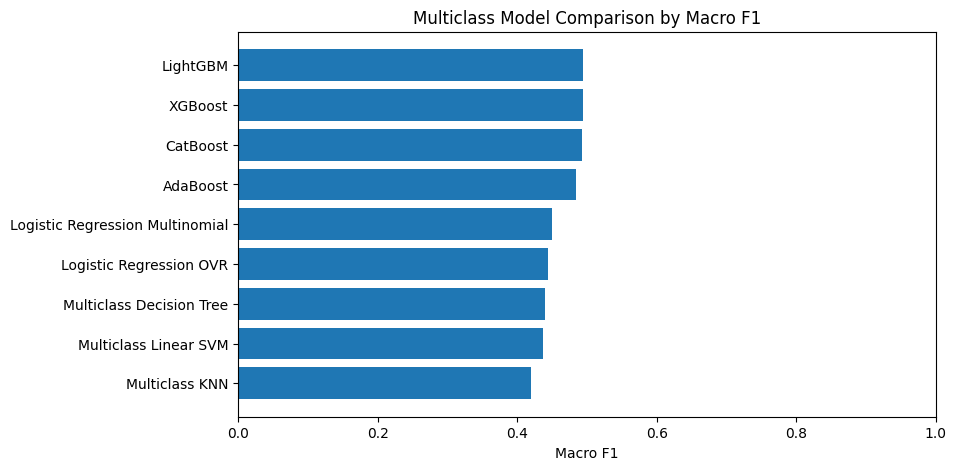

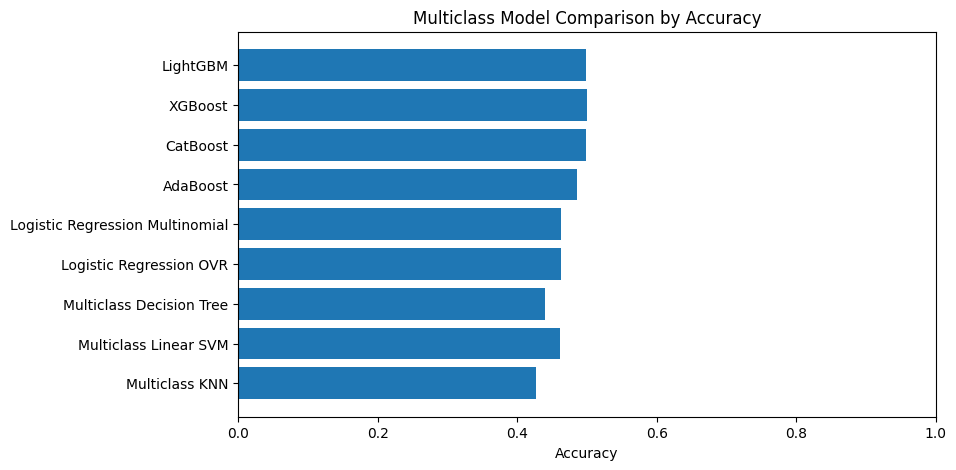

In [49]:
plot_multi = multiclass_results_df.sort_values("F1_macro")

plt.figure(figsize=(9, 5))
plt.barh(plot_multi["Model"], plot_multi["F1_macro"])
plt.xlabel("Macro F1")
plt.title("Multiclass Model Comparison by Macro F1")
plt.xlim(0, 1)
plt.show()

plt.figure(figsize=(9, 5))
plt.barh(plot_multi["Model"], plot_multi["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Multiclass Model Comparison by Accuracy")
plt.xlim(0, 1)
plt.show()

## 46. Confusion matrix for the best multiclass model

The best model is selected by Macro F1. The confusion matrix shows which delivery-speed categories are confused with each other.

Best multiclass model by Macro F1: LightGBM


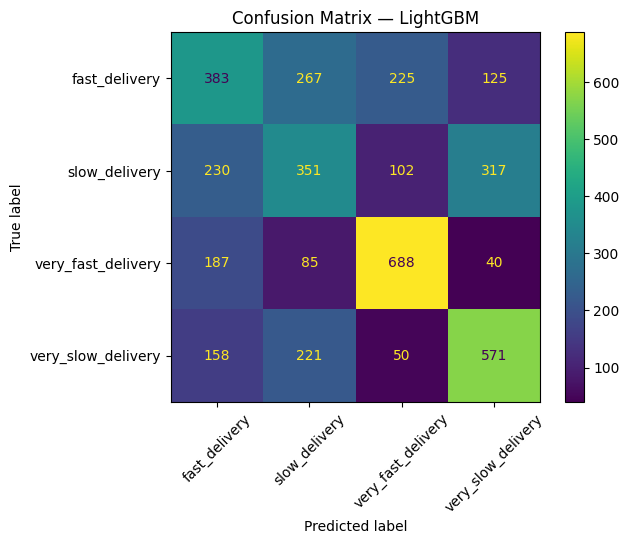

                    precision    recall  f1-score   support

     fast_delivery       0.40      0.38      0.39      1000
     slow_delivery       0.38      0.35      0.36      1000
very_fast_delivery       0.65      0.69      0.67      1000
very_slow_delivery       0.54      0.57      0.56      1000

          accuracy                           0.50      4000
         macro avg       0.49      0.50      0.49      4000
      weighted avg       0.49      0.50      0.49      4000



In [50]:
best_multiclass_model_name = multiclass_results_df.iloc[0]["Model"]
best_multiclass_model = fitted_multiclass_models[best_multiclass_model_name]
best_multiclass_pred = multiclass_predictions[best_multiclass_model_name]

print("Best multiclass model by Macro F1:", best_multiclass_model_name)

ConfusionMatrixDisplay.from_predictions(
    y_test_multi,
    best_multiclass_pred,
    display_labels=class_names_multi,
    xticks_rotation=45,
    cmap=None,
)
plt.title(f"Confusion Matrix — {best_multiclass_model_name}")
plt.show()

print(classification_report(
    y_test_multi,
    best_multiclass_pred,
    target_names=class_names_multi,
    zero_division=0,
))

## 47. Log-loss interpretation

Log loss evaluates the quality of predicted class probabilities, not only the final class label. A model is penalized heavily when it is confidently wrong. Therefore, log loss is most meaningful for models that naturally output calibrated or at least usable probabilities, such as multinomial logistic regression and many boosting models.

For SVM models without probability outputs, log loss is not reported because decision scores are not probabilities.

In [51]:
log_loss_table = (
    multiclass_results_df[["Model", "Log_loss"]]
    .dropna(subset=["Log_loss"])
    .sort_values("Log_loss", ascending=True)
)

display(log_loss_table.round(4))

,Model,Log_loss
7,LightGBM,1.0986
6,XGBoost,1.0988
8,CatBoost,1.1101
2,Logistic Regression Multinomial,1.1629
1,Logistic Regression OVR,1.1943
3,Multiclass KNN,1.3516
5,AdaBoost,1.3594
4,Multiclass Decision Tree,1.3984


## 48. KNN and Decision Tree tuning details

The assignment specifically asks for tuning K in KNN and tuning max depth in Decision Trees. The tables below show the strongest configurations found by cross-validation according to Macro F1.

In [52]:
knn_multi_cv = pd.DataFrame(fitted_multiclass_models["Multiclass KNN"].cv_results_)
knn_multi_cols = [
    "param_model__n_neighbors",
    "param_model__weights",
    "mean_test_score",
    "rank_test_score",
]
print("Best multiclass KNN configurations by cross-validated Macro F1:")
display(knn_multi_cv[knn_multi_cols].sort_values("rank_test_score").head(10))

tree_multi_cv = pd.DataFrame(fitted_multiclass_models["Multiclass Decision Tree"].cv_results_)
tree_multi_cols = [
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "mean_test_score",
    "rank_test_score",
]
print("Best multiclass Decision Tree configurations by cross-validated Macro F1:")
display(tree_multi_cv[tree_multi_cols].sort_values("rank_test_score").head(10))

Best multiclass KNN configurations by cross-validated Macro F1:


,param_model__n_neighbors,param_model__weights,mean_test_score,rank_test_score
9,25,distance,0.410658,1
8,25,uniform,0.410079,2
7,15,distance,0.402511,3
6,15,uniform,0.402089,4
5,9,distance,0.390953,5
4,9,uniform,0.390015,6
3,5,distance,0.382513,7
2,5,uniform,0.375967,8
0,3,uniform,0.369310,9
1,3,distance,0.368919,10


Best multiclass Decision Tree configurations by cross-validated Macro F1:


,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,rank_test_score
11,12,50,0.456044,1
8,8,50,0.455559,2
14,None,50,0.453741,3
7,8,30,0.453413,4
6,8,10,0.448439,5
3,5,10,0.444175,6
5,5,50,0.443159,7
10,12,30,0.442502,8
4,5,30,0.442489,9
13,None,30,0.438608,10


## 49. Discussion Q1 : Best multiclass-classification metric for this dataset

For this multiclass task, the best primary metric is **Macro F1**.

**Justification:**

- The task has four classes, and the goal is not only to perform well on the majority or easiest class.
- Macro F1 computes F1 separately for each class and then averages them equally.
- This makes it sensitive to poor performance on any one delivery-speed category.
- Accuracy can hide weak class-level performance. A model can achieve acceptable accuracy while systematically failing on one delivery-speed segment.
- Weighted F1 is useful as a secondary metric, but it can be dominated by larger classes if the target is not perfectly balanced.

Because the quartile-based target is designed to be roughly balanced, accuracy is not meaningless here. However, Macro F1 remains more informative because it explicitly checks whether the model is balanced across all four classes.

## 50. Discussion Q2 : How KNN and Decision Trees can be extended to multi-label classification

A multiclass problem assigns exactly one label to each observation. A multi-label problem allows each observation to have multiple labels at the same time. For example, one football player can simultaneously have played for the national team, have a previous injury, and have been a team captain.

**KNN extension to multi-label classification:**

KNN can be extended by looking at the labels of the nearest neighbors and estimating a probability for each label independently. For each possible label, the classifier checks how many of the K nearest neighbors have that label. A threshold, often 0.5, is then applied to decide whether the label should be assigned. This is sometimes called multi-label KNN.

**Decision Tree extension to multi-label classification:**

Decision Trees can be extended by storing a vector of labels at each leaf rather than a single class. Each terminal node estimates the probability of each label from the training samples that fall into that leaf. The final prediction is then a binary vector of labels after applying thresholds to those probabilities. Tree ensembles such as Random Forests can do the same by averaging label probabilities across trees.

The key difference is that the output is no longer a single class index. It is a vector of independent or partially dependent label decisions.

## 51. Discussion Q3 : Best metric for the football multi-label example

For the football example, I would use **sample-wise F1-score** as the main metric, supported by **Hamming loss** as a secondary diagnostic metric.

**Why sample-wise F1 is appropriate:**

Each player can belong to several classes at once:

- played for the national team;
- history of heart problems;
- previous knee injuries;
- former team captain.

In this setting, exact-match accuracy is too strict because it counts a prediction as wrong unless all four labels are predicted perfectly. For example, if a model correctly predicts three labels but misses one, exact-match accuracy gives no partial credit. That is often too harsh for practical multi-label evaluation.

Sample-wise F1 is better because it evaluates the overlap between the predicted label set and the true label set for each player. It balances precision and recall at the player level: it penalizes both adding wrong labels and missing true labels.

**Why Hamming loss is also useful:**

Hamming loss measures the fraction of individual labels that are predicted incorrectly. It is useful for identifying whether the model makes many label-level mistakes, even when exact label-set matches are rare.

Therefore, for this multi-label football problem, the main metric should be **sample-wise F1**, with **Hamming loss** reported as a complementary measure.

# Part 4 

This section answers the bonus questions from Assignment 2. The answers are written in the context of the Olist delivery-time problem developed above:

- **Regression target:** actual delivery time in days.
- **Binary classification target:** late delivery versus not-late delivery.
- **Multiclass classification target:** four delivery-speed classes.

The goal of this section is not to add unnecessary complexity. Instead, it connects core machine-learning concepts to the actual modeling choices made in this notebook.

## 52. Outliers in the regression target

Before answering the conceptual questions, it is useful to inspect the delivery-time target. Delivery times are usually right-skewed: most orders arrive within a moderate time window, while a small number take unusually long. This matters for regression loss functions because squared-error metrics punish extreme errors much more strongly than absolute-error metrics.

Delivery-time target summary, in days:


,delivery_time_days
count,96470.000
mean,12.558
std,9.546
min,0.533
1%,1.825
5%,3.015
25%,6.766
50%,10.217
75%,15.720
90%,23.096


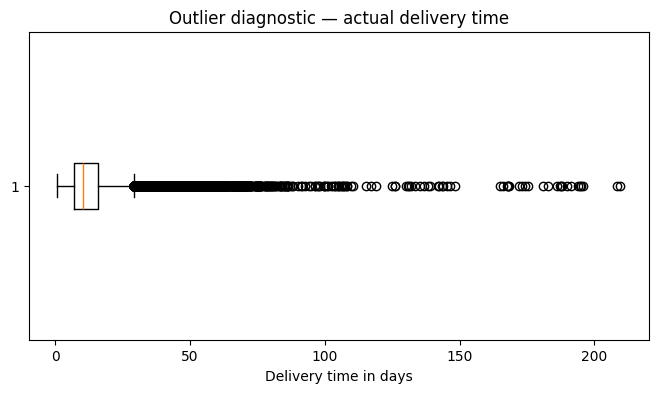

In [53]:
target_summary = df["delivery_time_days"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print("Delivery-time target summary, in days:")
display(target_summary.to_frame(name="delivery_time_days").round(3))

plt.figure(figsize=(8, 4))
plt.boxplot(df["delivery_time_days"].dropna(), vert=False)
plt.xlabel("Delivery time in days")
plt.title("Outlier diagnostic — actual delivery time")
plt.show()

## 53. Bias variance trade-off in regression models

The **bias variance trade-off** describes the tension between underfitting and overfitting.

A high-bias model is too simple. In this notebook, plain **Linear Regression** can have high bias if the relationship between freight value, product size, geography, seller/customer state, and delivery time is nonlinear. A high-bias model gives relatively stable predictions, but it may miss important structure.

A high-variance model is too flexible. For example, a deep **Decision Tree Regressor** can split the data into many small regions and fit idiosyncratic patterns in the training set. This may reduce training error but increase test error.

Regularized models such as **Ridge** and **LASSO** try to manage this trade-off. Ridge reduces variance by shrinking coefficients. LASSO also shrinks coefficients and can remove weak predictors entirely. Kernel-based regression can reduce bias by representing nonlinear relationships, but if the kernel space is too flexible, variance can increase.

For the Olist delivery-time task, the safest model is not necessarily the one with the lowest training error. The best model should generalize to unseen orders, sellers, product categories, and geographic combinations.

## 55. When Kernel Regression outperforms Linear Regression

Kernel Regression can outperform Linear Regression when the target depends on nonlinear interactions that are difficult to represent with a purely linear additive model.

In the Olist case, delivery time may depend on nonlinear patterns such as:

- the interaction between seller state and customer state;
- freight value becoming more informative only above a certain threshold;
- very heavy or bulky products behaving differently from ordinary products;
- weekend purchases or seasonal effects changing the delivery process;
- long-distance deliveries having nonlinear effects on expected delivery time.

A linear model assumes that each feature contributes a fixed additive effect. A kernel method implicitly maps the original features into a richer space where nonlinear relationships can be modeled. This is why an RBF-style kernel approximation may perform better when delivery time has curved or interaction-driven structure.

However, kernel models are not automatically superior. They can be slower, less interpretable, and more sensitive to hyperparameters. In a business setting, a slightly weaker but more interpretable Ridge model may be preferable if its error is close to the kernel model's error.

## 56. L1 versus L2 regularization

**L2 regularization**, used in Ridge Regression, penalizes the sum of squared coefficients. It shrinks coefficients smoothly toward zero but usually does not make them exactly zero.

**L1 regularization**, used in LASSO Regression, penalizes the sum of absolute coefficient values. It can shrink some coefficients exactly to zero, which produces a sparse model.

### When LASSO performs better

LASSO is often preferable when many predictors are irrelevant or redundant. In this notebook, one-hot encoding creates many categorical dummy variables, especially for product category, customer state, and seller state. If only some of these categories matter strongly for delivery time, LASSO can act as a feature selector.

### When Ridge performs better

Ridge is often preferable when many predictors have small but real effects and when predictors are correlated. In the Olist data, variables such as price, freight value, payment value, product size, and product weight may be correlated. Ridge handles this situation more smoothly than LASSO because it distributes coefficient shrinkage across correlated predictors instead of selecting one and discarding others.

### Why LASSO produces sparsity

LASSO produces sparsity because the absolute-value penalty has a sharp corner at zero. During optimization, that geometry makes zero an attractive solution for weak coefficients. Ridge uses a squared penalty with a smooth shape, so it usually shrinks coefficients close to zero but does not set them exactly to zero.

## 57. Why MAPE is unreliable in some datasets

MAPE measures error as a percentage of the true value. It is easy to interpret, but it can be unreliable.

The main problems are:

1. **Near-zero actual values:** if the true target is close to zero, a small absolute error can become an enormous percentage error.
2. **Undefined at zero:** if the actual value is zero, MAPE is mathematically undefined.
3. **Asymmetry:** overprediction and underprediction are not treated symmetrically in all practical settings.
4. **Business mismatch:** a percentage error may not reflect operational cost. For delivery time, being wrong by 2 days may matter more directly than being wrong by 20%.

For this notebook, **MAE** is a better main metric for delivery-time regression because it reports the average error directly in days. MAPE is still reported because the assignment requires it, but it should not be treated as the main model-selection metric.

## 58. Effect of outliers on regression models

Outliers can strongly affect regression models, especially when squared-error losses are used.

- **Linear Regression** is sensitive to extreme target values because it minimizes squared errors. A few very late deliveries can pull the fitted coefficients toward those cases.
- **Ridge Regression** is still based on squared error, so it remains sensitive to target outliers, although coefficient shrinkage can reduce instability.
- **LASSO Regression** also uses a squared-error objective in the usual implementation, so it is not fully robust to target outliers.
- **Decision Tree Regression** can isolate outliers into separate branches, but if the tree is too deep, this can become overfitting.
- **MAE and Median Absolute Error** are more robust evaluation metrics than MSE/RMSE when extreme errors exist.

For the Olist delivery-time problem, unusually long deliveries are not necessarily data errors; they may represent real operational failures. Therefore, they should not be removed automatically. A better approach is to report robust metrics, inspect residuals, and possibly create a separate analysis of extreme late deliveries.

## 59. Class imbalance in the binary task

Accuracy can be misleading when classes are imbalanced. In the Olist late-delivery task, the positive class is usually less frequent than the not-late class. A naive model can achieve high accuracy by predicting most orders as not late, while failing to identify the orders that matter most operationally.

Training-set class distribution:


,proportion
late_delivery,
not_late,0.9189
late,0.0811


Majority-class baseline metrics:


,Accuracy,Precision,Recall,F1
0,0.9189,0.0,0.0,0.0


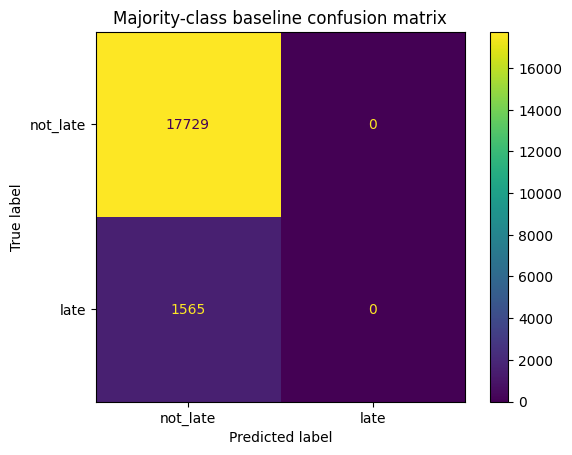

In [54]:
from sklearn.metrics import confusion_matrix

class_distribution = pd.Series(y_train_clf).value_counts(normalize=True).sort_index()
print("Training-set class distribution:")
display(class_distribution.rename(index={0: "not_late", 1: "late"}).to_frame("proportion").round(4))

majority_class = pd.Series(y_train_clf).mode()[0]
majority_pred = np.full_like(y_test_clf, fill_value=majority_class)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test_clf, majority_pred),
    "Precision": precision_score(y_test_clf, majority_pred, zero_division=0),
    "Recall": recall_score(y_test_clf, majority_pred, zero_division=0),
    "F1": f1_score(y_test_clf, majority_pred, zero_division=0),
}

print("Majority-class baseline metrics:")
display(pd.DataFrame([baseline_metrics]).round(4))

ConfusionMatrixDisplay.from_predictions(y_test_clf, majority_pred, display_labels=["not_late", "late"], cmap=None)
plt.title("Majority-class baseline confusion matrix")
plt.show()

## 60. Effect of class imbalance on binary metrics

Class imbalance changes the meaning of common classification metrics.

- **Accuracy** can look good even when the model ignores the minority class.
- **Precision** answers: among orders predicted late, how many were actually late?
- **Recall** answers: among all actually late orders, how many did the model find?
- **F1-score** balances precision and recall and is useful when false positives and false negatives both matter.
- **ROC AUC** can remain optimistic under class imbalance because it considers true-positive and false-positive rates over thresholds.
- **PR AUC** is often more informative when the positive class is rare because it focuses directly on precision and recall for the positive class.

For late-delivery prediction, accuracy is not sufficient. A model that misses most late deliveries is operationally weak even if its overall accuracy appears high. That is why this notebook uses F1 and PR AUC as important binary-classification metrics.

## 61. How the decision boundaries differ fundamentally

The models in this notebook learn different kinds of decision boundaries.

- **Logistic Regression** learns a linear boundary in the transformed feature space. After one-hot encoding and scaling, it separates classes using a weighted sum of features.
- **Linear SVM** also learns a linear boundary, but it focuses on maximizing the margin between classes.
- **Kernel SVM** can learn nonlinear boundaries by measuring similarity in a transformed kernel space. This is useful when the classes are not linearly separable.
- **KNN** has a local, instance-based boundary. Its decision surface can be irregular because predictions depend on nearby training examples.
- **Decision Trees** create axis-aligned rectangular regions by splitting one feature at a time.
- **Random Forests and boosting models** combine many trees, producing more flexible and smoother piecewise boundaries than a single tree.

In the Olist problem, tree-based and kernel-based methods may capture interactions between geography, freight, payment, and product attributes that linear models cannot express directly.

## 62. Effect of K in KNN

The value of **K** controls the smoothness of the KNN decision boundary.

- Small K: low bias, high variance; the model reacts strongly to local noise.
- Large K: high bias, lower variance; the model is smoother but may miss local structure.

The next cell visualizes the cross-validation behavior of KNN from the binary-classification tuning step.

,K,mean_test_score
0,3,0.0889
1,5,0.0530
2,9,0.0208
3,15,0.0057
4,25,0.0019


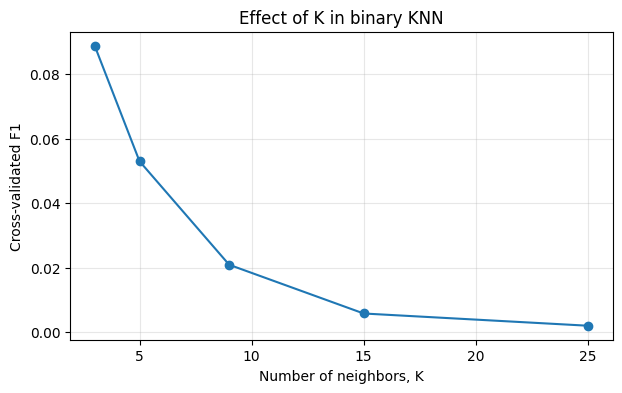

In [55]:
# Visualize the effect of K using the GridSearchCV results already computed in Part 2.

if "knn_cv_results" in globals():
    knn_effect = knn_cv_results.copy()
    knn_effect["K"] = knn_effect["param_model__n_neighbors"].astype(int)
    knn_plot = (
        knn_effect
        .groupby("K", as_index=False)["mean_test_score"]
        .max()
        .sort_values("K")
    )

    display(knn_plot.round(4))

    plt.figure(figsize=(7, 4))
    plt.plot(knn_plot["K"], knn_plot["mean_test_score"], marker="o")
    plt.xlabel("Number of neighbors, K")
    plt.ylabel("Cross-validated F1")
    plt.title("Effect of K in binary KNN")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Run the binary-classification KNN tuning cells first.")

## 63. Overfitting in Decision Trees

Decision Trees overfit easily because they can keep splitting until leaves become very small or pure. This means a tree can memorize accidental patterns in the training data.

### Why max depth is not enough

Limiting `max_depth` helps, but it is not sufficient by itself. A shallow tree can still overfit if leaves contain too few samples, and a deeper tree can generalize reasonably if it uses constraints such as `min_samples_leaf` and pruning.

Useful regularization techniques include:

1. **Limit maximum depth** with `max_depth`.
2. **Require enough samples per leaf** with `min_samples_leaf`.
3. **Require enough samples before a split** with `min_samples_split`.
4. **Limit the number of leaf nodes** with `max_leaf_nodes`.
5. **Cost-complexity pruning** with `ccp_alpha`.

### How pruning works

Pruning removes branches that add little predictive value. Cost-complexity pruning balances training fit against tree complexity. A branch is kept only if its improvement justifies the added complexity.

,max_depth,mean_test_score
1,3,0.2474
2,5,0.2622
3,8,0.2706
0,12,0.2608
4,None,0.2494


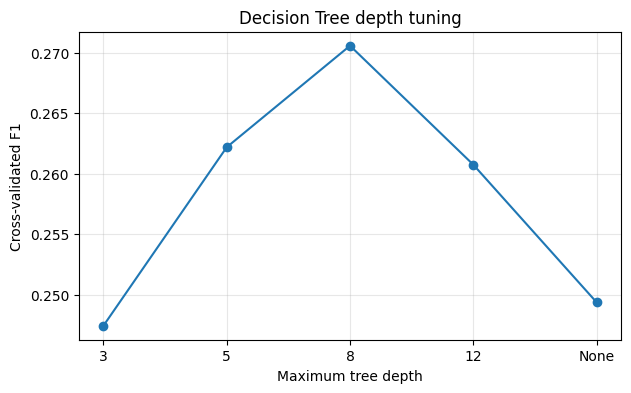

In [56]:
# Visualize decision-tree tuning results from Part 2.

if "dt_cv_results" in globals():
    dt_effect = dt_cv_results.copy()
    dt_effect["max_depth"] = dt_effect["param_model__max_depth"].astype(str)
    dt_plot = (
        dt_effect
        .groupby("max_depth", as_index=False)["mean_test_score"]
        .max()
    )

    # Sort numerical depths while keeping possible 'None' values at the end.
    def _depth_sort_value(x):
        return 999 if x == "None" else int(x)

    dt_plot = dt_plot.sort_values("max_depth", key=lambda s: s.map(_depth_sort_value))
    display(dt_plot.round(4))

    plt.figure(figsize=(7, 4))
    plt.plot(dt_plot["max_depth"], dt_plot["mean_test_score"], marker="o")
    plt.xlabel("Maximum tree depth")
    plt.ylabel("Cross-validated F1")
    plt.title("Decision Tree depth tuning")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Run the binary decision-tree tuning cells first.")

## 64. Why tree-based models are good feature selectors

Tree-based models are useful feature selectors because they split on variables that reduce impurity or prediction error. A feature used frequently near the top of a tree is likely to explain important variation in the target.

In Random Forests and boosting models, feature importance is aggregated across many trees. This helps identify predictors that repeatedly improve classification or regression performance.

However, tree-based feature importance must be interpreted carefully:

- impurity-based importance can favor high-cardinality or continuous features;
- correlated features may split importance across themselves;
- importance does not prove causality;
- permutation importance is often a better diagnostic when computationally feasible.

For the Olist dataset, tree models can highlight whether delivery time is more strongly associated with estimated delivery days, freight cost, customer/seller geography, product size, or payment features.

## 65. Micro F1 versus Macro F1 versus Weighted F1

**Macro F1** computes F1 separately for each class and then takes the unweighted average. Every class receives equal importance. Macro F1 is a better reflection when minority classes matter and the goal is balanced performance across all classes.

**Weighted F1** also computes F1 per class, but weights each class by its support. This can be misleading when one or two large classes dominate the dataset. A model can perform poorly on small classes while still getting a reasonable weighted F1.

**Micro F1** aggregates all true positives, false positives, and false negatives before computing F1. In single-label multiclass classification, micro F1 is often very close to accuracy. It favors large classes because each individual observation contributes equally, so majority classes dominate the total count.

For the four-class delivery-speed task, **Macro F1** is the most appropriate primary metric because it forces the evaluation to consider all four classes, not only the most common or easiest classes.

## 66. Multiclass versus multi-label classification

A **multiclass** problem assigns exactly one class to each observation. In this notebook, each order belongs to one delivery-speed class only: very fast, fast, slow, or very slow.

A **multi-label** problem allows multiple labels to be active for the same observation. In the football example from the assignment, a player can simultaneously have played for the national team, have a history of heart problems, have previous knee injuries, and have been a team captain.

### Output space

- Multiclass: one label from K possible classes.
- Multi-label: a binary vector of length K, where each label can be 0 or 1.

### Loss functions

- Multiclass: usually softmax cross-entropy.
- Multi-label: usually binary cross-entropy independently for each label.

### Thresholding

- Multiclass: choose the class with the highest probability.
- Multi-label: apply a threshold to each label probability independently.

### Metrics

- Multiclass: accuracy, macro F1, weighted F1, log loss.
- Multi-label: sample-wise F1, Hamming loss, Jaccard score, label-wise precision/recall/F1.

### Why KNN and Decision Trees can be extended to multi-label classification

KNN can predict a vector of labels by averaging the label vectors of neighboring samples and thresholding each label. Decision Trees can store multi-label distributions in leaves and output several labels at once, often through multi-output classification implementations.

## 67. Precision recall trade-off

Precision and recall move against each other when the classification threshold changes.

- Lowering the threshold predicts more orders as late. This usually increases recall but may reduce precision.
- Raising the threshold predicts fewer orders as late. This usually increases precision but may reduce recall.

For late-delivery prediction, the preferred threshold depends on business cost. If missing a late delivery is costly, recall should be prioritized. If falsely flagging normal orders wastes resources, precision should be prioritized.

In [57]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, threshold_values = precision_recall_curve(y_test_clf, best_binary_score)

# precision_values and recall_values have one more element than threshold_values.
threshold_table = pd.DataFrame({
    "threshold": threshold_values,
    "precision": precision_values[:-1],
    "recall": recall_values[:-1],
})
threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"] /
    (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)
)

# Display representative thresholds across the score range.
representative_thresholds = threshold_table.iloc[np.linspace(0, len(threshold_table) - 1, min(10, len(threshold_table))).astype(int)]
print(f"Precision--recall threshold behavior for: {best_binary_model_name}")
display(representative_thresholds.round(4))

best_threshold_row = threshold_table.sort_values("f1", ascending=False).head(1)
print("Threshold with strongest F1 on this test split:")
display(best_threshold_row.round(4))

Precision--recall threshold behavior for: Random Forest


,threshold,precision,recall,f1
0,0.0785,0.0811,1.0000,0.1501
2143,0.2277,0.0894,0.9802,0.1639
4286,0.2656,0.0988,0.9476,0.1790
6429,0.2971,0.1107,0.9099,0.1974
8572,0.3291,0.1244,0.8524,0.2172
10716,0.3640,0.1432,0.7847,0.2422
12859,0.4051,0.1701,0.6990,0.2736
15002,0.4596,0.2140,0.5866,0.3136
17145,0.5429,0.3040,0.4166,0.3515
19289,0.8416,1.0000,0.0006,0.0013


Threshold with strongest F1 on this test split:


,threshold,precision,recall,f1
17009,0.536,0.2968,0.4326,0.3521


## 68. ROC curve vs Precision Recall curve

The **ROC curve** plots true positive rate against false positive rate across thresholds. It is useful for measuring ranking ability, but it can look overly optimistic when the negative class is much larger than the positive class.

The **Precision Recall curve** plots precision against recall. It focuses directly on performance for the positive class. This makes it more informative when the positive class is rare or more important.

For the Olist binary task, the positive class is late delivery. Since late deliveries are operationally important and may be less frequent than on-time deliveries, PR AUC is a valuable complement to ROC AUC.

## 69. If unlimited time and resources were available, how could the models be improved?

With unlimited time and resources, I would improve this project in five directions.

### Better preprocessing

I would handle outliers more carefully, validate timestamp consistency, check missing values by source table, and compare robust target transformations such as log-transformed delivery time.

### Better features

I would engineer richer logistics features, especially geographic distance between seller and customer, state-pair routes, holiday indicators, month-level seasonality, product-category-level historical averages, seller reliability, and rolling late-delivery rates.

### Better validation

A random split is acceptable for a first notebook, but delivery behavior changes over time. A time-based split would better test whether the model generalizes to future orders.

### Better models

I would tune gradient boosting models more systematically, especially LightGBM, XGBoost, and CatBoost. These models are often strong for tabular data with nonlinearities and interactions.

### Better metrics

For regression, I would keep MAE as the main metric but also report high-percentile absolute errors to understand worst-case delays. For binary classification, I would choose thresholds based on the cost of false alarms versus missed late deliveries. For multiclass classification, I would keep Macro F1 as the main metric and inspect per-class recall.

### Better interpretability

I would add permutation importance, SHAP-style explanations where appropriate, partial dependence plots, and route-level error analysis. This would show not only which model performs best, but also why it performs well or poorly.

## 70. Final Part 4 summary

The main lesson from the bonus section is that model choice cannot be separated from data structure and evaluation design.

For the Olist dataset:

- delivery-time regression is affected by skewness and outliers, so MAE is more interpretable than MSE alone;
- late-delivery classification can suffer from class imbalance, so F1 and PR AUC are more informative than accuracy alone;
- four-class delivery-speed prediction should use Macro F1 because all classes should matter;
- regularization, pruning, thresholding, and validation design are as important as the choice of algorithm.

This completes Parts 1--4 of Assignment 2.


# Bonus Points (mentioned in the begining)

This final section adds the extra-credit elements described near the beginning of the assignment. The goal is not to add unnecessary complexity, but to make the notebook more informative, interpretable, and easier to evaluate.

The added bonus elements are:

1. a concise project README generated from the notebook results;
2. unified summary tables for regression, binary classification, and multiclass classification;
3. model comparison visualizations, including performance versus training time;
4. error analysis for regression, binary classification, and multiclass classification;
5. interpretation-oriented outputs, including feature importance and model behavior summaries;
6. cross-validation stability summaries where grid search results are available;
7. a small educational decision-boundary visualization on a 2D toy dataset.



## 71. Checklist

The assignment states that bonus credit should reward genuine insight, clarity, and useful additions rather than overengineering. The following cells therefore focus on interpretation, comparison, error analysis, and reproducibility.


In [69]:

bonus_checklist = pd.DataFrame({
    "Bonus element": [
        "README.md summary",
        "Unified model comparison table",
        "Model comparison visualizations",
        "Regression error analysis",
        "Binary classification error analysis",
        "Multiclass classification error analysis",
        "Interpretability summary",
        "Cross-validation stability summary",
        "Training time / complexity comparison",
        "2D decision-boundary demonstration",
    ],
    "Implemented": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes, where GridSearchCV was used",
        "Yes",
        "Yes, as an educational toy example",
    ],
    "Why it is useful": [
        "Makes the GitHub repository easier to understand.",
        "Allows all model families to be compared in one place.",
        "Makes performance differences easier to inspect visually.",
        "Shows where the delivery-time regression model fails most.",
        "Shows false positives and false negatives for late-delivery prediction.",
        "Shows which delivery-speed classes are confused most often.",
        "Connects model outputs to feature effects and business interpretation.",
        "Shows whether tuned models are stable across folds.",
        "Prevents choosing a model only because of one metric.",
        "Shows how different classifiers create fundamentally different boundaries.",
    ]
})

display(bonus_checklist)


,Bonus element,Implemented,Why it is useful
0,README.md summary,Yes,Makes the GitHub repository easier to understand.
1,Unified model comparison table,Yes,Allows all model families to be compared in on...
2,Model comparison visualizations,Yes,Makes performance differences easier to inspec...
3,Regression error analysis,Yes,Shows where the delivery-time regression model...
4,Binary classification error analysis,Yes,Shows false positives and false negatives for ...
5,Multiclass classification error analysis,Yes,Shows which delivery-speed classes are confuse...
6,Interpretability summary,Yes,Connects model outputs to feature effects and ...
7,Cross-validation stability summary,"Yes, where GridSearchCV was used",Shows whether tuned models are stable across f...
8,Training time / complexity comparison,Yes,Prevents choosing a model only because of one ...
9,2D decision-boundary demonstration,"Yes, as an educational toy example",Shows how different classifiers create fundame...



## 72. Unified model comparison dashboard

The three modeling tasks have different objectives and different primary metrics:

- Regression: lower MAE is better.
- Binary classification: higher F1 is better.
- Multiclass classification: higher Macro F1 is better.

The table below collects the best available summary values from all previous sections. This makes the notebook easier to review than reading each section separately.


In [59]:

summary_frames = []

if "results_df" in globals():
    reg_summary = results_df.copy()
    reg_summary["Task"] = "Regression: delivery-time prediction"
    reg_summary["Primary_metric"] = "MAE"
    reg_summary["Primary_score"] = reg_summary["MAE"]
    reg_summary["Primary_direction"] = "lower is better"
    reg_summary["Secondary_metric"] = "R2"
    reg_summary["Secondary_score"] = reg_summary["R2"]
    summary_frames.append(reg_summary[[
        "Task", "Model", "Primary_metric", "Primary_score", "Primary_direction",
        "Secondary_metric", "Secondary_score", "Fit_time_sec", "Best_params"
    ]])

if "binary_results_df" in globals():
    bin_summary = binary_results_df.copy()
    bin_summary["Task"] = "Binary classification: late delivery"
    bin_summary["Primary_metric"] = "F1"
    bin_summary["Primary_score"] = bin_summary["F1"]
    bin_summary["Primary_direction"] = "higher is better"
    bin_summary["Secondary_metric"] = "PR_AUC"
    bin_summary["Secondary_score"] = bin_summary["PR_AUC"]
    summary_frames.append(bin_summary[[
        "Task", "Model", "Primary_metric", "Primary_score", "Primary_direction",
        "Secondary_metric", "Secondary_score", "Fit_time_sec", "Best_params"
    ]])

if "multiclass_results_df" in globals():
    multi_summary = multiclass_results_df.copy()
    multi_summary["Task"] = "Multiclass classification: delivery-speed group"
    multi_summary["Primary_metric"] = "Macro F1"
    multi_summary["Primary_score"] = multi_summary["F1_macro"]
    multi_summary["Primary_direction"] = "higher is better"
    multi_summary["Secondary_metric"] = "Accuracy"
    multi_summary["Secondary_score"] = multi_summary["Accuracy"]
    summary_frames.append(multi_summary[[
        "Task", "Model", "Primary_metric", "Primary_score", "Primary_direction",
        "Secondary_metric", "Secondary_score", "Fit_time_sec", "Best_params"
    ]])

if summary_frames:
    all_model_summary = pd.concat(summary_frames, ignore_index=True)
    display(all_model_summary.sort_values(["Task", "Primary_score"], ascending=[True, False]).round(4))
else:
    print("Run Parts 1, 2, and 3 first to build the unified model comparison table.")


,Task,Model,Primary_metric,Primary_score,Primary_direction,Secondary_metric,Secondary_score,Fit_time_sec,Best_params
5,Binary classification: late delivery,Random Forest,F1,0.3361,higher is better,PR_AUC,0.2731,293.9231,"{'model__max_depth': None, 'model__max_feature..."
6,Binary classification: late delivery,Decision Tree,F1,0.2763,higher is better,PR_AUC,0.2241,39.3521,"{'model__max_depth': 8, 'model__min_samples_le..."
7,Binary classification: late delivery,Kernel SVM (RBF),F1,0.2663,higher is better,PR_AUC,0.2120,3447.8693,"{'model__C': 1.0, 'model__gamma': 'scale'}"
8,Binary classification: late delivery,Linear SVM,F1,0.2246,higher is better,PR_AUC,0.1715,27.3707,{'model__C': 0.1}
9,Binary classification: late delivery,Logistic Regression,F1,0.2228,higher is better,PR_AUC,0.1724,672.1469,"{'model__C': 0.1, 'model__penalty': 'l1'}"
10,Binary classification: late delivery,KNN,F1,0.1243,higher is better,PR_AUC,0.1234,289.1816,"{'model__n_neighbors': 3, 'model__weights': 'd..."
11,Multiclass classification: delivery-speed group,LightGBM,Macro F1,0.4947,higher is better,Accuracy,0.4982,3.7553,None
12,Multiclass classification: delivery-speed group,XGBoost,Macro F1,0.4940,higher is better,Accuracy,0.4995,4.6038,None
13,Multiclass classification: delivery-speed group,CatBoost,Macro F1,0.4930,higher is better,Accuracy,0.4990,6.1101,None
14,Multiclass classification: delivery-speed group,AdaBoost,Macro F1,0.4849,higher is better,Accuracy,0.4858,17.8878,None



## 73. Performance versus training time

A useful model is not always the model with the best score. For practical work, training time, interpretability, and deployment cost also matter. The following plots compare primary performance and fitting time for each task.


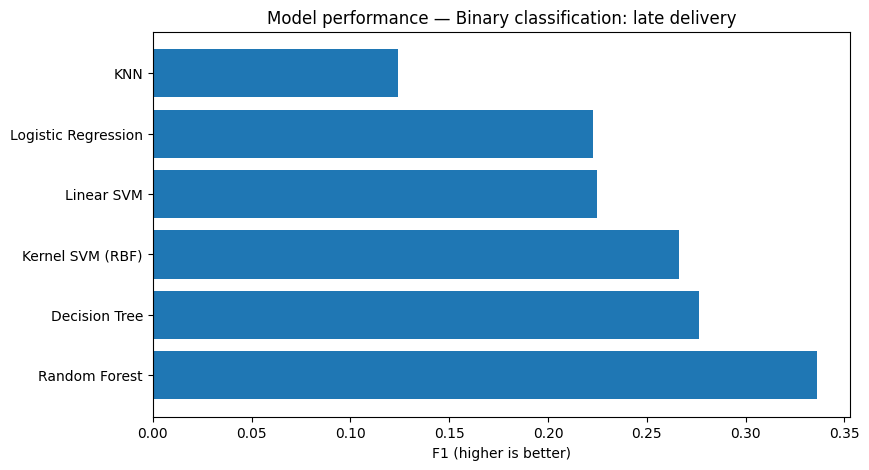

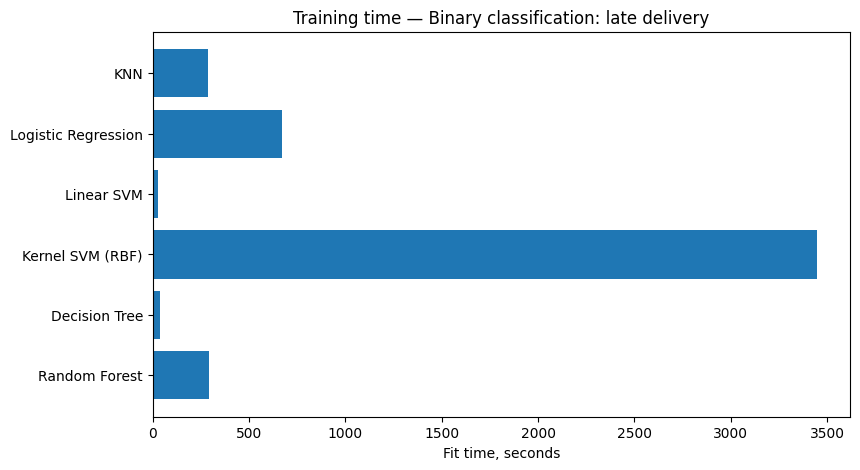

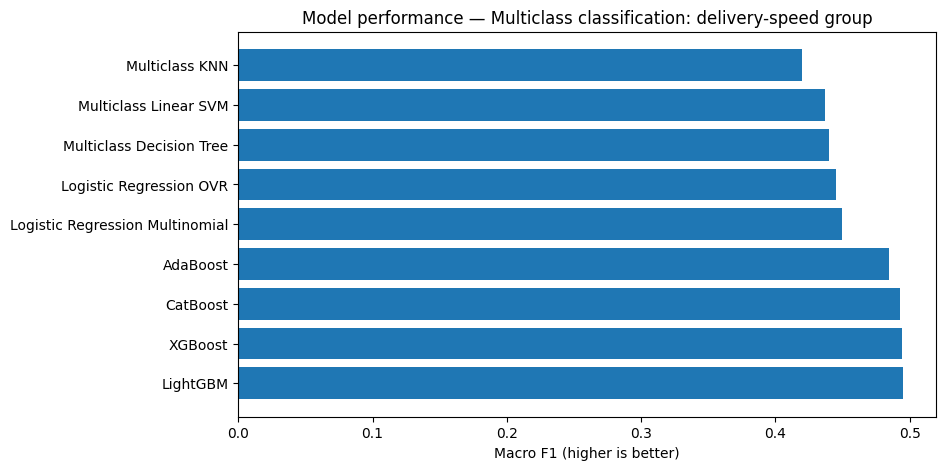

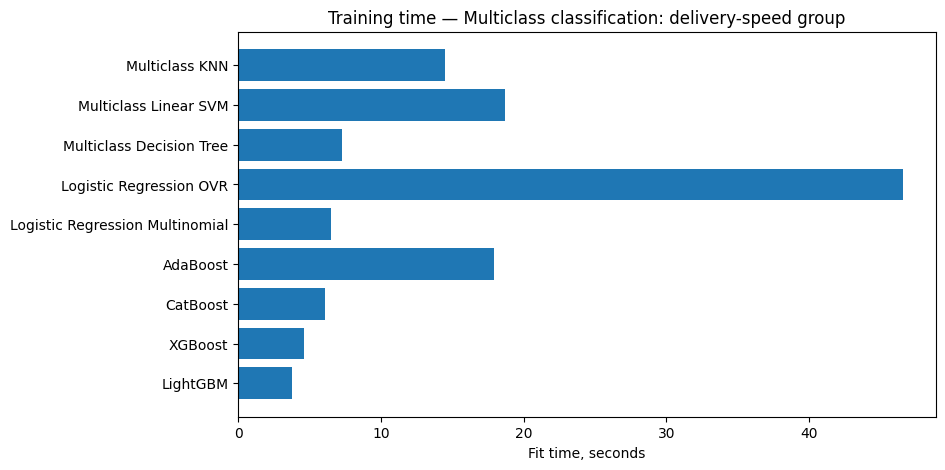

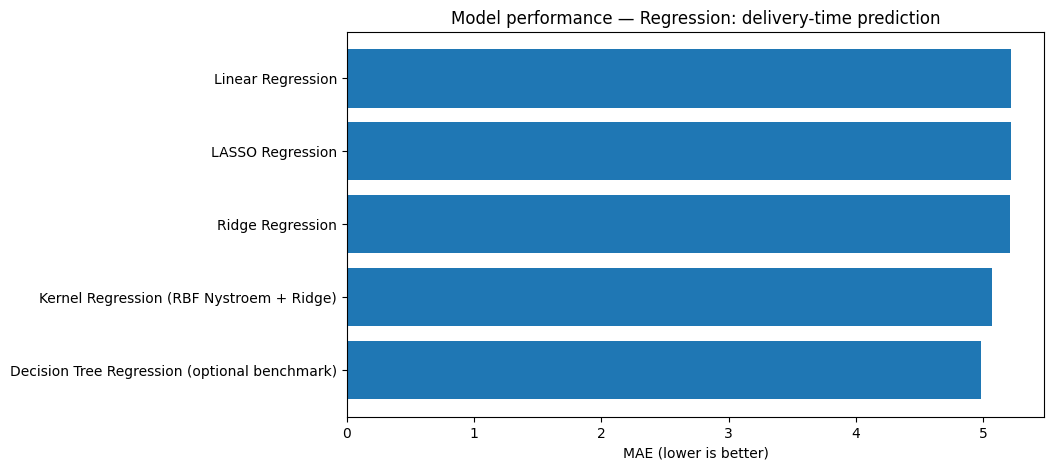

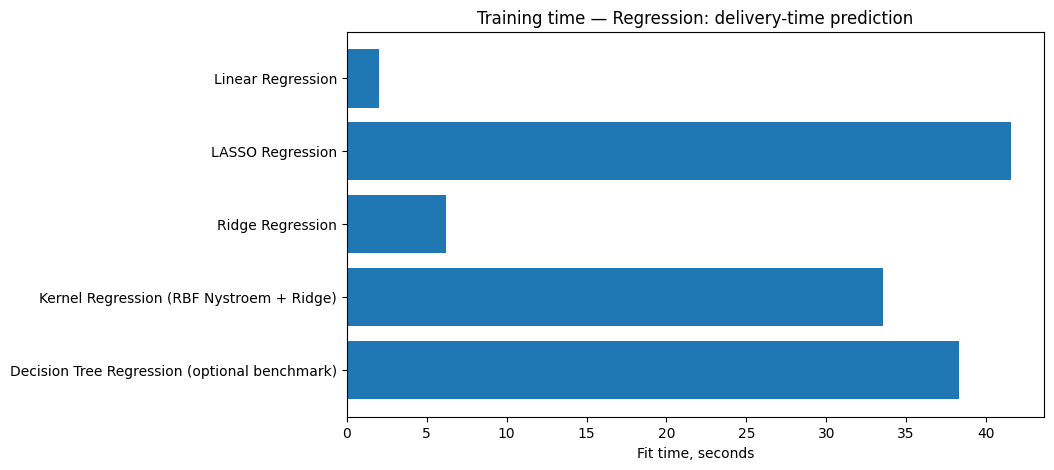

In [60]:

if "all_model_summary" in globals():
    for task_name, task_df in all_model_summary.groupby("Task"):
        plot_df = task_df.copy()
        plot_df = plot_df.sort_values("Primary_score", ascending=(plot_df["Primary_direction"].iloc[0] == "lower is better"))

        plt.figure(figsize=(9, 5))
        plt.barh(plot_df["Model"], plot_df["Primary_score"])
        plt.xlabel(f"{plot_df['Primary_metric'].iloc[0]} ({plot_df['Primary_direction'].iloc[0]})")
        plt.title(f"Model performance — {task_name}")
        plt.show()

        plt.figure(figsize=(9, 5))
        plt.barh(plot_df["Model"], plot_df["Fit_time_sec"])
        plt.xlabel("Fit time, seconds")
        plt.title(f"Training time — {task_name}")
        plt.show()
else:
    print("Run the previous summary-table cell first.")



## 74. Optional interactive model comparison

If Plotly is installed, the next cell creates an interactive chart. If Plotly is not installed, the notebook automatically falls back to the static plots above, so execution remains reproducible on a minimal environment.


In [61]:

try:
    import plotly.express as px

    if "all_model_summary" in globals():
        fig = px.scatter(
            all_model_summary,
            x="Fit_time_sec",
            y="Primary_score",
            color="Task",
            hover_name="Model",
            hover_data=["Primary_metric", "Primary_direction", "Secondary_metric", "Secondary_score"],
            title="Interactive model comparison: performance versus training time",
        )
        fig.show()
    else:
        print("Run the unified model comparison cell first.")
except Exception as exc:
    print("Plotly is not available in this environment. Static plots above are sufficient.")
    print("Reason:", exc)



## 75. Regression error analysis


In [62]:

if all(name in globals() for name in ["X_test", "y_test", "best_pred", "best_model_name"]):
    regression_error_df = X_test.copy()
    regression_error_df["actual_delivery_days"] = np.asarray(y_test)
    regression_error_df["predicted_delivery_days"] = np.asarray(best_pred)
    regression_error_df["residual_actual_minus_predicted"] = (
        regression_error_df["actual_delivery_days"] - regression_error_df["predicted_delivery_days"]
    )
    regression_error_df["absolute_error_days"] = regression_error_df["residual_actual_minus_predicted"].abs()

    cols_to_show = [
        "actual_delivery_days",
        "predicted_delivery_days",
        "residual_actual_minus_predicted",
        "absolute_error_days",
        "estimated_delivery_days",
        "customer_state",
        "seller_state",
        "product_category_name",
        "total_price",
        "total_freight",
        "item_count",
    ]
    cols_to_show = [c for c in cols_to_show if c in regression_error_df.columns]

    print(f"Worst regression errors for: {best_model_name}")
    display(regression_error_df[cols_to_show].sort_values("absolute_error_days", ascending=False).head(15).round(3))

    print("Absolute-error distribution, in days:")
    display(regression_error_df["absolute_error_days"].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame().round(3))
else:
    print("Run Part 1 first so that regression predictions are available.")


Worst regression errors for: Decision Tree Regression (optional benchmark)


,actual_delivery_days,predicted_delivery_days,residual_actual_minus_predicted,absolute_error_days,estimated_delivery_days,customer_state,seller_state,product_category_name,total_price,total_freight,item_count
66407,181.061,22.122,158.938,158.938,28.377,GO,SP,utilidades_domesticas,34.90,17.78,1.0
74759,172.140,22.583,149.556,149.556,39.372,RR,SP,esporte_lazer,236.00,30.85,1.0
64738,138.878,17.338,121.540,121.540,34.184,AM,CE,alimentos,149.90,38.01,1.0
73803,124.998,17.999,106.999,106.999,61.532,GO,SC,esporte_lazer,504.00,44.42,2.0
13672,104.883,3.231,101.652,101.652,8.164,SP,SP,cama_mesa_banho,164.90,12.25,1.0
81343,109.829,12.545,97.284,97.284,21.233,RJ,SP,telefonia,29.99,15.10,1.0
50891,99.660,5.969,93.690,93.690,16.081,SP,SP,papelaria,115.90,12.02,1.0
35213,107.065,14.504,92.561,92.561,26.483,SP,SP,moveis_decoracao,1259.00,95.09,1.0
84806,103.758,13.793,89.965,89.965,27.023,SP,PR,sinalizacao_e_seguranca,69.99,18.37,1.0
44590,96.282,7.501,88.781,88.781,13.658,SP,SP,cool_stuff,219.99,14.09,1.0


Absolute-error distribution, in days:


,absolute_error_days
count,19294.000
mean,4.979
std,6.015
min,0.000
50%,3.456
75%,6.240
90%,10.479
95%,14.428
99%,26.873
max,158.938



### Interpretation of regression errors

For this dataset, large regression errors are expected when delivery behavior is driven by factors not fully available in the public tables, such as carrier-level routing, temporary logistics disruptions. This is one reason why MAE is more interpretable than MSE: it reports the typical error directly in days, while MSE can be dominated by a small number of extreme delivery failures.



## 76. Binary classification error analysis

For late-delivery prediction, the most important diagnostic distinction is between false negatives and false positives:

- False negative: the model predicts not late, but the order is actually late.
- False positive: the model predicts late, but the order is actually not late.

False negatives are operationally costly because a late order is missed before it happens. False positives may still be acceptable if they trigger low-cost monitoring.


In [63]:

if all(name in globals() for name in ["X_test_clf", "y_test_clf", "best_binary_pred", "best_binary_score", "best_binary_model_name"]):
    binary_error_df = X_test_clf.copy()
    binary_error_df["actual_late"] = np.asarray(y_test_clf)
    binary_error_df["predicted_late"] = np.asarray(best_binary_pred)
    binary_error_df["late_score"] = np.asarray(best_binary_score)

    def binary_error_type(row):
        if row["actual_late"] == 1 and row["predicted_late"] == 0:
            return "False negative: missed late delivery"
        if row["actual_late"] == 0 and row["predicted_late"] == 1:
            return "False positive: unnecessary late warning"
        if row["actual_late"] == 1 and row["predicted_late"] == 1:
            return "True positive"
        return "True negative"

    binary_error_df["error_type"] = binary_error_df.apply(binary_error_type, axis=1)

    print(f"Binary error profile for: {best_binary_model_name}")
    display(binary_error_df["error_type"].value_counts().to_frame("count"))

    error_examples = binary_error_df[binary_error_df["actual_late"] != binary_error_df["predicted_late"]].copy()
    error_examples["confidence_gap"] = np.abs(error_examples["late_score"] - 0.5)

    cols_to_show = [
        "error_type",
        "actual_late",
        "predicted_late",
        "late_score",
        "confidence_gap",
        "estimated_delivery_days",
        "customer_state",
        "seller_state",
        "product_category_name",
        "total_price",
        "total_freight",
        "item_count",
    ]
    cols_to_show = [c for c in cols_to_show if c in error_examples.columns]

    print("Most confident binary-classification mistakes:")
    display(error_examples[cols_to_show].sort_values("confidence_gap", ascending=False).head(15).round(4))
else:
    print("Run Part 2 first so that binary-classification predictions are available.")


Binary error profile for: Random Forest


,count
error_type,
True negative,15423
False positive: unnecessary late warning,2306
False negative: missed late delivery,783
True positive,782


Most confident binary-classification mistakes:


,error_type,actual_late,predicted_late,late_score,confidence_gap,estimated_delivery_days,customer_state,seller_state,product_category_name,total_price,total_freight,item_count
5702,False negative: missed late delivery,1,0,0.1287,0.3713,24.4989,SP,SP,cama_mesa_banho,39.99,11.85,1.0
19278,False negative: missed late delivery,1,0,0.1491,0.3509,16.4524,SP,SP,automotivo,18.90,7.78,1.0
71652,False positive: unnecessary late warning,0,1,0.8370,0.3370,21.1243,RJ,SP,moveis_decoracao,69.90,20.98,1.0
83427,False negative: missed late delivery,1,0,0.1646,0.3354,14.4505,SP,SP,telefonia,21.99,7.78,1.0
34419,False negative: missed late delivery,1,0,0.1672,0.3328,22.5411,SP,SP,brinquedos,55.50,12.73,1.0
3981,False negative: missed late delivery,1,0,0.1674,0.3326,34.6120,SP,PR,moveis_decoracao,35.99,14.08,1.0
87580,False negative: missed late delivery,1,0,0.1694,0.3306,46.3277,MG,MG,beleza_saude,79.90,13.58,1.0
67723,False negative: missed late delivery,1,0,0.1710,0.3290,26.2165,SP,SP,telefonia,19.90,11.85,1.0
50084,False negative: missed late delivery,1,0,0.1721,0.3279,13.3607,SP,SP,instrumentos_musicais,35.90,7.87,1.0
17005,False positive: unnecessary late warning,0,1,0.8265,0.3265,21.4941,RJ,SP,cama_mesa_banho,33.99,19.32,1.0



## 77. Multiclass classification error analysis

For the four-class delivery-speed task, the model may confuse neighboring classes, for example `fast_delivery` with `very_fast_delivery` or `slow_delivery` with `very_slow_delivery`. Such errors are less severe than confusing the fastest class with the slowest class.


In [64]:

if all(name in globals() for name in ["y_test_multi", "best_multiclass_pred", "class_names_multi", "best_multiclass_model_name"]):
    true_idx = np.asarray(y_test_multi).astype(int)
    pred_idx = np.asarray(best_multiclass_pred).astype(int)

    true_labels = np.array(class_names_multi)[true_idx]
    pred_labels = np.array(class_names_multi)[pred_idx]

    multi_error_df = pd.DataFrame({
        "true_class": true_labels,
        "predicted_class": pred_labels,
        "true_class_index": true_idx,
        "predicted_class_index": pred_idx,
    })
    multi_error_df["is_correct"] = multi_error_df["true_class"] == multi_error_df["predicted_class"]
    multi_error_df["class_distance"] = (multi_error_df["true_class_index"] - multi_error_df["predicted_class_index"]).abs()

    print(f"Multiclass error profile for: {best_multiclass_model_name}")
    print("Accuracy from this diagnostic table:", round(multi_error_df["is_correct"].mean(), 4))

    print("Errors by true and predicted class:")
    display(
        multi_error_df[~multi_error_df["is_correct"]]
        .groupby(["true_class", "predicted_class"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("Severity of multiclass mistakes measured by class-index distance:")
    display(
        multi_error_df[~multi_error_df["is_correct"]]["class_distance"]
        .value_counts()
        .sort_index()
        .rename_axis("class_distance")
        .reset_index(name="count")
    )
else:
    print("Run Part 3 first so that multiclass predictions are available.")


Multiclass error profile for: LightGBM
Accuracy from this diagnostic table: 0.4982
Errors by true and predicted class:


,true_class,predicted_class,count
5,slow_delivery,very_slow_delivery,317
0,fast_delivery,slow_delivery,267
3,slow_delivery,fast_delivery,230
1,fast_delivery,very_fast_delivery,225
10,very_slow_delivery,slow_delivery,221
6,very_fast_delivery,fast_delivery,187
9,very_slow_delivery,fast_delivery,158
2,fast_delivery,very_slow_delivery,125
4,slow_delivery,very_fast_delivery,102
7,very_fast_delivery,slow_delivery,85


Severity of multiclass mistakes measured by class-index distance:


,class_distance,count
0,1,774
1,2,950
2,3,283



## 78. Cross-validation stability summary

In [65]:

def extract_best_cv_summary(model_dict, task_name, score_name, larger_is_better=True):
    rows = []
    for model_name, estimator in model_dict.items():
        if not hasattr(estimator, "cv_results_"):
            continue
        cv = pd.DataFrame(estimator.cv_results_).copy()
        if cv.empty:
            continue

        best_idx = int(estimator.best_index_) if hasattr(estimator, "best_index_") else int(cv["rank_test_score"].idxmin())
        mean_score = cv.loc[best_idx, "mean_test_score"]
        std_score = cv.loc[best_idx, "std_test_score"]

        # Regression models were tuned using negative MAE.
        if not larger_is_better:
            mean_score = -mean_score
            score_name_display = score_name
        else:
            score_name_display = score_name

        rows.append({
            "Task": task_name,
            "Model": model_name,
            "CV_score": score_name_display,
            "Best_CV_mean": mean_score,
            "Best_CV_std": std_score,
            "Best_params": getattr(estimator, "best_params_", None),
        })
    return pd.DataFrame(rows)

cv_tables = []
if "fitted_models" in globals():
    cv_tables.append(extract_best_cv_summary(
        fitted_models,
        task_name="Regression",
        score_name="MAE from negative MAE scoring",
        larger_is_better=False,
    ))

if "fitted_binary_models" in globals():
    cv_tables.append(extract_best_cv_summary(
        fitted_binary_models,
        task_name="Binary classification",
        score_name="F1",
        larger_is_better=True,
    ))

if "fitted_multiclass_models" in globals():
    cv_tables.append(extract_best_cv_summary(
        fitted_multiclass_models,
        task_name="Multiclass classification",
        score_name="Macro F1",
        larger_is_better=True,
    ))

cv_tables = [t for t in cv_tables if not t.empty]
if cv_tables:
    cv_stability_summary = pd.concat(cv_tables, ignore_index=True)
    display(cv_stability_summary.sort_values(["Task", "Best_CV_std"]).round(4))
else:
    print("No GridSearchCV objects found yet. Run the modeling sections first.")


,Task,Model,CV_score,Best_CV_mean,Best_CV_std,Best_params
5,Binary classification,Linear SVM,F1,0.2254,0.0013,{'model__C': 0.1}
4,Binary classification,Logistic Regression,F1,0.2259,0.0021,"{'model__C': 0.1, 'model__penalty': 'l1'}"
6,Binary classification,Kernel SVM (RBF),F1,0.2524,0.0040,"{'model__C': 1.0, 'model__gamma': 'scale'}"
7,Binary classification,KNN,F1,0.0889,0.0041,"{'model__n_neighbors': 3, 'model__weights': 'd..."
9,Binary classification,Random Forest,F1,0.3210,0.0051,"{'model__max_depth': None, 'model__max_feature..."
8,Binary classification,Decision Tree,F1,0.2706,0.0121,"{'model__max_depth': 8, 'model__min_samples_le..."
11,Multiclass classification,Logistic Regression OVR,Macro F1,0.4438,0.0022,"{'model__estimator__C': 1.0, 'model__estimator..."
12,Multiclass classification,Logistic Regression Multinomial,Macro F1,0.4515,0.0027,{'model__C': 0.1}
10,Multiclass classification,Multiclass Linear SVM,Macro F1,0.4357,0.0032,{'model__C': 1.0}
13,Multiclass classification,Multiclass KNN,Macro F1,0.4107,0.0046,"{'model__n_neighbors': 25, 'model__weights': '..."



## 79. Interpretability and complexity summary

The table below summarizes each model family in terms of interpretability, flexibility, and computational cost. This supports our request to compare models not only by predictive performance but also by complexity and interpretability.


In [66]:

model_interpretability = pd.DataFrame([
    {
        "Model family": "Linear / Logistic Regression",
        "Interpretability": "High",
        "Flexibility": "Low to medium",
        "Computational cost": "Low",
        "Main strength": "Clear coefficient-based interpretation after preprocessing.",
        "Main limitation": "May underfit nonlinear relationships.",
    },
    {
        "Model family": "Ridge / LASSO",
        "Interpretability": "High to medium",
        "Flexibility": "Low to medium",
        "Computational cost": "Low",
        "Main strength": "Regularization improves stability; LASSO can select features.",
        "Main limitation": "Still mostly linear in the engineered feature space.",
    },
    {
        "Model family": "Kernel methods / Kernel SVM",
        "Interpretability": "Low",
        "Flexibility": "High",
        "Computational cost": "Medium to high",
        "Main strength": "Can model nonlinear decision surfaces.",
        "Main limitation": "Harder to interpret and more expensive on large datasets.",
    },
    {
        "Model family": "KNN",
        "Interpretability": "Medium",
        "Flexibility": "Medium to high",
        "Computational cost": "High at prediction time",
        "Main strength": "Simple, local, non-parametric behavior.",
        "Main limitation": "Sensitive to scaling, irrelevant features, and high dimensionality.",
    },
    {
        "Model family": "Decision Tree",
        "Interpretability": "Medium to high",
        "Flexibility": "High",
        "Computational cost": "Low to medium",
        "Main strength": "Captures nonlinear interactions and is easy to visualize conceptually.",
        "Main limitation": "Overfits easily without pruning or leaf-size constraints.",
    },
    {
        "Model family": "Random Forest / Boosting",
        "Interpretability": "Medium to low",
        "Flexibility": "High",
        "Computational cost": "Medium to high",
        "Main strength": "Strong predictive performance and useful feature importance.",
        "Main limitation": "Less transparent than a single tree or linear model.",
    },
])

display(model_interpretability)


,Model family,Interpretability,Flexibility,Computational cost,Main strength,Main limitation
0,Linear / Logistic Regression,High,Low to medium,Low,Clear coefficient-based interpretation after p...,May underfit nonlinear relationships.
1,Ridge / LASSO,High to medium,Low to medium,Low,Regularization improves stability; LASSO can s...,Still mostly linear in the engineered feature ...
2,Kernel methods / Kernel SVM,Low,High,Medium to high,Can model nonlinear decision surfaces.,Harder to interpret and more expensive on larg...
3,KNN,Medium,Medium to high,High at prediction time,"Simple, local, non-parametric behavior.","Sensitive to scaling, irrelevant features, and..."
4,Decision Tree,Medium to high,High,Low to medium,Captures nonlinear interactions and is easy to...,Overfits easily without pruning or leaf-size c...
5,Random Forest / Boosting,Medium to low,High,Medium to high,Strong predictive performance and useful featu...,Less transparent than a single tree or linear ...



## 80. README.md 


In [ ]:

from pathlib import Path

readme_text = f"""# ADS 2026 Assignment 2 : Olist Brazilian E-Commerce Modeling

## Dataset
This project uses the Olist Brazilian E-Commerce Public Dataset.(Which was used in Assignment1)


## Main modeling tasks

### Part 1 : Regression
The regression task predicts actual delivery time in days. The main target is `delivery_time_days`.

Models evaluated:
- Linear Regression
- Kernel Regression using RBF Nystroem features + Ridge
- Ridge Regression
- LASSO Regression
- Decision Tree Regression as an optional benchmark

Primary metric: MAE, because the prediction error is directly interpretable as days of delivery error and is less dominated by extreme outliers than MSE.

### Part 2 : Binary Classification
The binary task predicts whether an order is delivered late relative to the estimated delivery date.

Target:
- 1 = late delivery
- 0 = on-time or early delivery

Models evaluated:
- Logistic Regression
- Linear SVM
- Kernel SVM
- KNN with K tuning
- Decision Tree with depth/leaf tuning
- Random Forest

Primary metric: F1, supported by ROC AUC and PR AUC, because late delivery can be imbalanced and both missed late orders and false warnings matter.

### Part 3 : Multiclass Classification
The multiclass task predicts four delivery-speed classes:
- very fast delivery
- fast delivery
- slow delivery
- very slow delivery

Models evaluated:
- Multiclass SVM
- Logistic Regression with One-vs-Rest
- Multinomial Logistic Regression
- KNN with K tuning
- Decision Tree with tuning
- AdaBoost
- XGBoost / LightGBM / CatBoost when installed

Primary metric: Macro F1, because all delivery-speed classes should matter even when their supports differ.

### Part 4 : Challenging Questions
The notebook answers the conceptual questions about bias--variance trade-off, kernel regression, L1/L2 regularization, MAPE, outliers, class imbalance, decision boundaries, KNN, decision-tree overfitting, tree feature selection, F1 variants, multilabel versus multiclass learning, precision--recall trade-off, ROC versus PR curves, and future improvements.

## Bonus additions
The notebook also includes:
- unified model comparison tables;
- model comparison visualizations;
- regression, binary, and multiclass error analysis;
- feature-importance and interpretability summaries;
- cross-validation stability summaries;
- training time and complexity comparison;
- an educational 2D decision-boundary demonstration.

## Reproducibility notes
The notebook uses a fixed `RANDOM_STATE` where applicable. Some models are intentionally capped or tuned with modest grids to remain executable on a normal laptop.
"""

readme_path = Path("README.md")
readme_path.write_text(readme_text, encoding="utf-8")

2588


## 81. Educational decision-boundary visualization on a 2D toy dataset

This cell is not used to evaluate the Olist dataset. It is included only to show conceptual understanding of how decision boundaries differ across model families. The assignment explicitly mentions decision-boundary visualization for 2D toy datasets as a possible bonus addition.


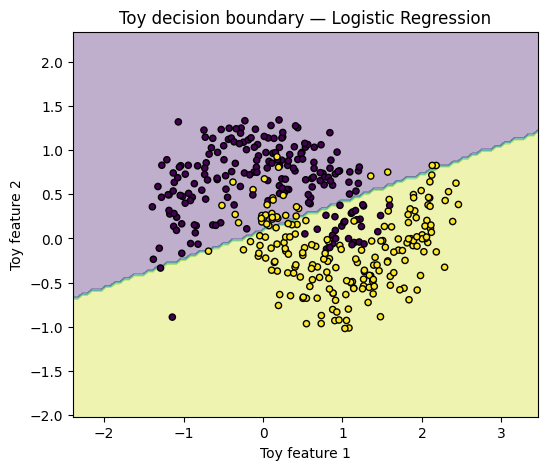

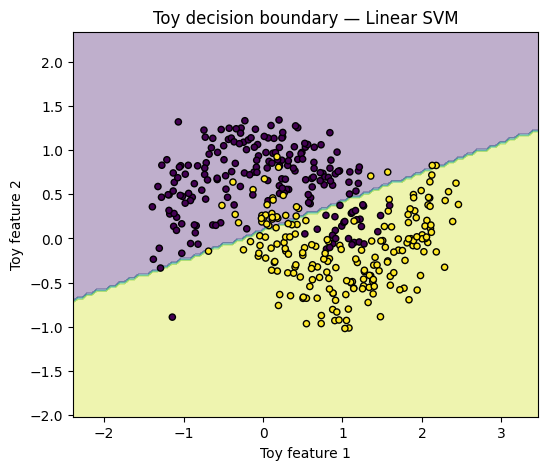

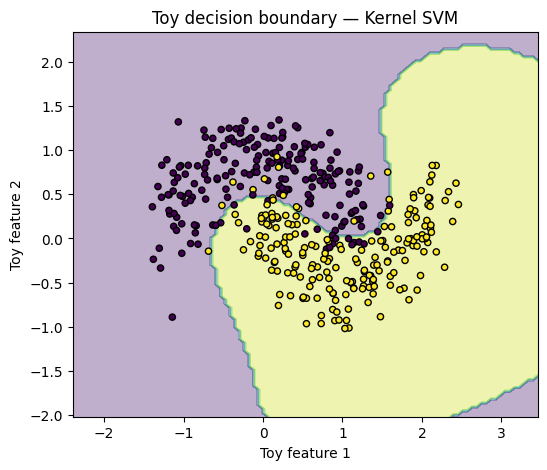

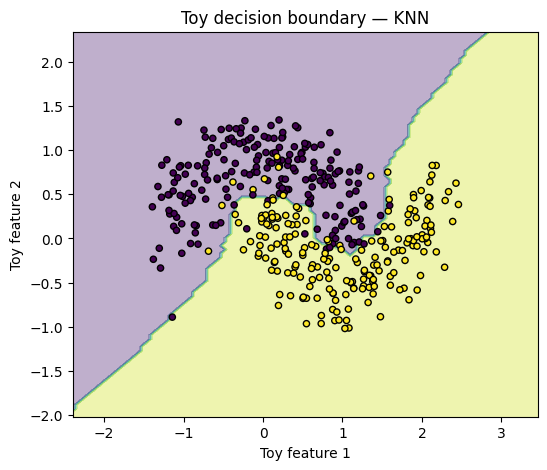

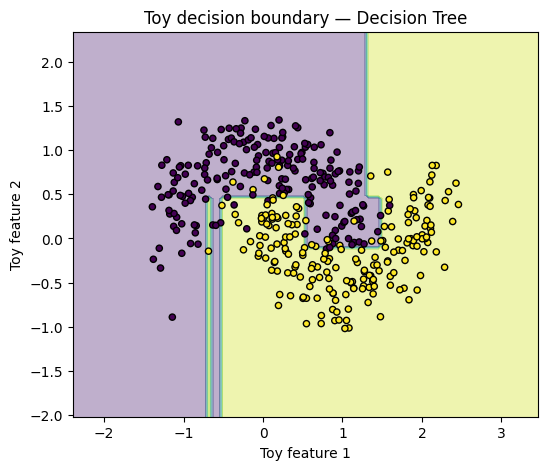

In [68]:

from sklearn.datasets import make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_toy, y_toy = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

boundary_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "Linear SVM": make_pipeline(StandardScaler(), LinearSVC(max_iter=10000, random_state=RANDOM_STATE)),
    "Kernel SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
}

for name, clf in boundary_models.items():
    clf.fit(X_toy, y_toy)
    plt.figure(figsize=(6, 5))
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_toy,
        response_method="predict",
        alpha=0.35,
        ax=plt.gca(),
    )
    plt.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, s=20, edgecolor="k")
    plt.title(f"Toy decision boundary — {name}")
    plt.xlabel("Toy feature 1")
    plt.ylabel("Toy feature 2")
    plt.show()
